# Nykaa Skincare Analysis

## Objective
This project aims to analyze Nykaa skincare product data to:
- Identify key factors influencing product ratings
- Understand pricing and discount strategies
- Analyze brand positioning in the skincare market
- Nykaa has 2600+ products with no ingredient-level search — this analysis surfaces patterns invisible to buyers

## Dataset Collection

The dataset was created from scratch using web scraping and API extraction.

- Nykaa is a JavaScript-based website, so I used **Puppeteer** to scrape product data like name, brand, rating, and ingredients.
- I separately collected product URLs to get unique product IDs.
- Using browser DevTools, I found Nykaa’s internal API which provided additional details like price, discount, and review count.
- I merged all the data and enriched it using API calls.

### Final Dataset
- ~2600+ products
- Features: name, brand, rating, ingredients, price, discount, reviews, category

### Limitations
- Some products had missing values (ingredients or URLs)
- API required authentication, so scraping depended on session cookies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
nykaa=pd.read_json('nykaa_enriched.json')
nykaa.head()

,name,brand,rating,ingredients,url,mrp,final_price,discount_pct,review_count,category_l2,category_l3,DEBUG_KEYS,GLOBALS
0,Neutrogena Hydro Boost Hyaluronic Acid Water G...,Neutrogena,4.5,"[<p>water, dimethicone, glycerin, dimethicone/...",https://www.nykaa.com/neutrogena-hydro-boost-w...,525.0,473.0,10.0,19648.0,Moisturizers,Face Moisturizer & Day Cream,NaN,NaN
1,CeraVe Moisturizer Cream For Dry Skin With Cer...,CeraVe,4.4,"[<p>ceramide, hyaluronic acid</p><p>aqua / wat...",https://www.nykaa.com/cerave-moisturizing-crea...,395.0,336.0,15.0,109225.0,Moisturizers,Face Moisturizer & Day Cream,NaN,NaN
2,Dot & Key Mango Detan Gel Sunscreen In-Vivo Te...,Dot & Key,4.5,"[<p>aqua, ethylhexyl methoxycinnamate (and) bu...",https://www.nykaa.com/dot-key-mango-detan-gel-...,445.0,387.0,13.0,130022.0,Sun Care,Face Sunscreen,NaN,NaN
3,LANEIGE Lip Glowy Balm,LANEIGE,4.6,"[<p>hydrogenated polyisobutene, phytosteryl / ...",https://www.nykaa.com/laneige-lip-glowy-balm/p...,1150.0,1035.0,10.0,1524.0,Lip Care,Lip Balm,NaN,NaN
4,Beauty of Joseon Relief Sunscreen Rice + Probi...,Beauty of Joseon,4.5,[<p><b>key ingredients :</b></p><ul><li><b>ric...,https://www.nykaa.com/beauty-of-joseon-relief-...,1570.0,1570.0,0.0,809.0,Sun Care,Face Sunscreen,NaN,NaN


In [5]:
nykaa.drop(columns=['DEBUG_KEYS','GLOBALS'],inplace=True)

In [6]:
nykaa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2684 entries, 0 to 2683
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          2624 non-null   object 
 1   brand         2624 non-null   object 
 2   rating        2612 non-null   float64
 3   ingredients   2624 non-null   object 
 4   url           2684 non-null   object 
 5   mrp           2418 non-null   float64
 6   final_price   2418 non-null   float64
 7   discount_pct  2418 non-null   float64
 8   review_count  2418 non-null   float64
 9   category_l2   2081 non-null   object 
 10  category_l3   2273 non-null   object 
dtypes: float64(5), object(6)
memory usage: 230.8+ KB


## Dataset Assessment


*  Last rows contain only NaN values

* ingredients has HTML tags (`<p>`, `<b>`) and encoded text (`&amp;`)

* product_id can be extracted from url
* review_count should be converted to integer
* null values in different columns
* duplicate products present

In [7]:
print(nykaa['name'].isnull().sum())

60


In [8]:
nykaa[nykaa['name'].isnull()]

,name,brand,rating,ingredients,url,mrp,final_price,discount_pct,review_count,category_l2,category_l3
2624,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2625,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2626,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2627,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2628,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2629,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2630,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2631,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2632,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN
2633,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(nykaa.duplicated(subset=['name']).sum())

213


Removing rows where ` name` was missing since it is a key identifier




In [10]:
nykaa1=nykaa.dropna(subset=['name'])
nykaa1.tail()

,name,brand,rating,ingredients,url,mrp,final_price,discount_pct,review_count,category_l2,category_l3
2619,Dot & Key Strawberry Dew Tinted Sunscreen SPF ...,Dot & Key,4.4,"[<p>aqua, ethylhexyl methoxycinnamate, butyl m...",https://www.nykaa.com/dot-key-strawberry-dew-t...,445.0,387.0,13.0,130022.0,Sun Care,Face Sunscreen
2620,Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...,Nykaa Skin,4.5,[],https://www.nykaa.com/nykaa-skin-secrets-sheet...,100.0,100.0,0.0,155363.0,Masks,Sheet Masks
2621,The Derma Co Sali-Cinamide Anti-Acne Face Wash...,The Derma Co,4.4,[],https://www.nykaa.com/the-derma-co-sali-cinami...,299.0,269.0,10.0,10238.0,Cleansers,Face Wash
2622,Bioderma Niacinamide Moisturizer - Atoderm Cre...,Bioderma,4.5,"[<p>aqua/water/eau, paraffinum liquidum / mine...",https://www.nykaa.com/bioderma-atoderm-creme-u...,699.0,699.0,0.0,40836.0,Moisturizers,Face Moisturizer & Day Cream
2623,Cetaphil Moisturising Cream,Cetaphil,4.5,"[<p>purified water, polyglycerylmethacrylate &...",https://www.nykaa.com/cetaphil-moisturising-cr...,459.0,427.0,7.0,374967.0,Cleansers,Face Wash


In [11]:
print(nykaa1.duplicated(subset=['name']).sum())

154


In [12]:
dupes = nykaa1[nykaa1.duplicated(subset=['name'], keep=False)]
dupes[['name', 'brand', 'mrp', 'ingredients']]

,name,brand,mrp,ingredients
0,Neutrogena Hydro Boost Hyaluronic Acid Water G...,Neutrogena,525.0,"[<p>water, dimethicone, glycerin, dimethicone/..."
1,CeraVe Moisturizer Cream For Dry Skin With Cer...,CeraVe,395.0,"[<p>ceramide, hyaluronic acid</p><p>aqua / wat..."
2,Dot & Key Mango Detan Gel Sunscreen In-Vivo Te...,Dot & Key,445.0,"[<p>aqua, ethylhexyl methoxycinnamate (and) bu..."
3,LANEIGE Lip Glowy Balm,LANEIGE,1150.0,"[<p>hydrogenated polyisobutene, phytosteryl / ..."
4,Beauty of Joseon Relief Sunscreen Rice + Probi...,Beauty of Joseon,1570.0,[<p><b>key ingredients :</b></p><ul><li><b>ric...
...,...,...,...,...
2619,Dot & Key Strawberry Dew Tinted Sunscreen SPF ...,Dot & Key,445.0,"[<p>aqua, ethylhexyl methoxycinnamate, butyl m..."
2620,Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...,Nykaa Skin,100.0,[]
2621,The Derma Co Sali-Cinamide Anti-Acne Face Wash...,The Derma Co,299.0,[]
2622,Bioderma Niacinamide Moisturizer - Atoderm Cre...,Bioderma,699.0,"[<p>aqua/water/eau, paraffinum liquidum / mine..."


In [13]:
dupes_grouped = dupes.groupby('name').size().reset_index(name='count')
print(dupes_grouped.sort_values('count', ascending=False))

                                                  name  count
76   Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...     22
72   Nykaa Anti-Acne Face Wash With Salicylic Acid,...      7
30                Dr. Sheth's Ceramide & Vitamin C Oil      4
104  The Derma Co Sali-Cinamide Anti-Acne Face Wash...      4
8    Bio-Oil Skincare Infused with Rosemary for Str...      4
..                                                 ...    ...
102  The Derma Co 2.5% Benzoyl Peroxide Gel Face Wa...      2
105  The Formularx Hydraveil Moisturizer With Ectoi...      2
106  The Ordinary Glycolic Acid 7% Exfoliating Solu...      2
107  The Pink Foundry Dark Spot & Hyperpigmentation...      2
109  VLCC 7X Ultra Whitening & Brightening Charcoal...      2

[110 rows x 2 columns]


In [14]:
example = nykaa1[nykaa1['name'] == 'Neutrogena Hydro Boost Hyaluronic Acid Water Gel Light Face Moisturizer For Normal, Dry & Oily Skin']
print(example[['name', 'brand', 'mrp', 'rating', 'url']].to_string())

                                                                                                     name       brand    mrp  rating                                                                                                   url
0     Neutrogena Hydro Boost Hyaluronic Acid Water Gel Light Face Moisturizer For Normal, Dry & Oily Skin  Neutrogena  525.0     4.5  https://www.nykaa.com/neutrogena-hydro-boost-water-gel/p/875156?productId=875156&pps=11&skuId=362587
48    Neutrogena Hydro Boost Hyaluronic Acid Water Gel Light Face Moisturizer For Normal, Dry & Oily Skin  Neutrogena  525.0     4.5  https://www.nykaa.com/neutrogena-hydro-boost-water-gel/p/875156?productId=875156&pps=11&skuId=362587
2604  Neutrogena Hydro Boost Hyaluronic Acid Water Gel Light Face Moisturizer For Normal, Dry & Oily Skin  Neutrogena  525.0     4.5  https://www.nykaa.com/neutrogena-hydro-boost-water-gel/p/875156?productId=875156&pps=11&skuId=362587


Dropping duplicates based on `name`, keeping the first occurrence
- The first occurrence corresponds to the primary SKU as listed by Nykaa
(variant duplicates like different sizes share the same name but have
separate product IDs — keeping first retains the most prominent listing).

In [15]:
nykaa1 = nykaa1.drop_duplicates(subset='name', keep='first')



In [16]:
print(nykaa1.duplicated(subset=['name']).sum())

0


In [17]:
nykaa1['ingredients'].head()

,ingredients
0,"[<p>water, dimethicone, glycerin, dimethicone/..."
1,"[<p>ceramide, hyaluronic acid</p><p>aqua / wat..."
2,"[<p>aqua, ethylhexyl methoxycinnamate (and) bu..."
3,"[<p>hydrogenated polyisobutene, phytosteryl / ..."
4,[<p><b>key ingredients :</b></p><ul><li><b>ric...


In [90]:
nykaa1.to_csv('nykaa.csv')   ## Export before HTML cleaning — used to manually inspect raw ingredient format

Cleaning ingredients column by removing HTML tags, decoding characters, standardizing text (lowercase & spacing),

In [19]:
import re

def clean_ingredients(ingredient_list):
    if not isinstance(ingredient_list, list):
        return []

    cleaned = []
    for ingredient in ingredient_list:
        ingredient = re.sub('<[^>]+>', '', ingredient)
        ingredient = ingredient.replace('&amp;','&')
        ingredient = ingredient.strip().lower()
        if len(ingredient) > 2:
            cleaned.append(ingredient)

    return cleaned

nykaa1['ingredients'] = nykaa1['ingredients'].apply(clean_ingredients)

In [20]:
nykaa1

,name,brand,rating,ingredients,url,mrp,final_price,discount_pct,review_count,category_l2,category_l3
0,Neutrogena Hydro Boost Hyaluronic Acid Water G...,Neutrogena,4.5,"[water, dimethicone, glycerin, dimethicone/vin...",https://www.nykaa.com/neutrogena-hydro-boost-w...,525.0,473.0,10.0,19648.0,Moisturizers,Face Moisturizer & Day Cream
1,CeraVe Moisturizer Cream For Dry Skin With Cer...,CeraVe,4.4,"[ceramide, hyaluronic acidaqua / water / eau, ...",https://www.nykaa.com/cerave-moisturizing-crea...,395.0,336.0,15.0,109225.0,Moisturizers,Face Moisturizer & Day Cream
2,Dot & Key Mango Detan Gel Sunscreen In-Vivo Te...,Dot & Key,4.5,"[aqua, ethylhexyl methoxycinnamate (and) butyl...",https://www.nykaa.com/dot-key-mango-detan-gel-...,445.0,387.0,13.0,130022.0,Sun Care,Face Sunscreen
3,LANEIGE Lip Glowy Balm,LANEIGE,4.6,"[hydrogenated polyisobutene, phytosteryl / iso...",https://www.nykaa.com/laneige-lip-glowy-balm/p...,1150.0,1035.0,10.0,1524.0,Lip Care,Lip Balm
4,Beauty of Joseon Relief Sunscreen Rice + Probi...,Beauty of Joseon,4.5,[key ingredients :rice extract 30% + grain fer...,https://www.nykaa.com/beauty-of-joseon-relief-...,1570.0,1570.0,0.0,809.0,Sun Care,Face Sunscreen
...,...,...,...,...,...,...,...,...,...,...,...
2599,Elizabeth Arden Advanced Ceramide Capsules,Elizabeth Arden,4.5,[],,NaN,NaN,NaN,NaN,NaN,NaN
2600,Focallure FA-L12 Glisten Opal Hydrating Lip Balm,Focallure,4.9,"[diisostearyl malate, dipentaerythrityl hexahy...",,NaN,NaN,NaN,NaN,NaN,NaN
2601,Paula's Choice Boost Pro-Collagen Multi-Peptid...,Paula's Choice,5.0,"[aqua (solvent), glycerin (humectant), pentyle...",,NaN,NaN,NaN,NaN,NaN,NaN
2602,The Face Shop Jeju Volcanic Lava Fresh Nose St...,The Face Shop,4.4,"[pvp, purified water, silica, titanium dioxide...",,NaN,NaN,NaN,NaN,NaN,NaN


Removed rows where:

* ingredients list was empty AND
mrp was missing
(considered unusable data for our analysis)

In [21]:
cond1 = nykaa1['ingredients'].apply(lambda x: len(x) == 0)
cond2 = nykaa1['mrp'].isna()
nykaa1 = nykaa1[~(cond1 & cond2)]
nykaa1

,name,brand,rating,ingredients,url,mrp,final_price,discount_pct,review_count,category_l2,category_l3
0,Neutrogena Hydro Boost Hyaluronic Acid Water G...,Neutrogena,4.5,"[water, dimethicone, glycerin, dimethicone/vin...",https://www.nykaa.com/neutrogena-hydro-boost-w...,525.0,473.0,10.0,19648.0,Moisturizers,Face Moisturizer & Day Cream
1,CeraVe Moisturizer Cream For Dry Skin With Cer...,CeraVe,4.4,"[ceramide, hyaluronic acidaqua / water / eau, ...",https://www.nykaa.com/cerave-moisturizing-crea...,395.0,336.0,15.0,109225.0,Moisturizers,Face Moisturizer & Day Cream
2,Dot & Key Mango Detan Gel Sunscreen In-Vivo Te...,Dot & Key,4.5,"[aqua, ethylhexyl methoxycinnamate (and) butyl...",https://www.nykaa.com/dot-key-mango-detan-gel-...,445.0,387.0,13.0,130022.0,Sun Care,Face Sunscreen
3,LANEIGE Lip Glowy Balm,LANEIGE,4.6,"[hydrogenated polyisobutene, phytosteryl / iso...",https://www.nykaa.com/laneige-lip-glowy-balm/p...,1150.0,1035.0,10.0,1524.0,Lip Care,Lip Balm
4,Beauty of Joseon Relief Sunscreen Rice + Probi...,Beauty of Joseon,4.5,[key ingredients :rice extract 30% + grain fer...,https://www.nykaa.com/beauty-of-joseon-relief-...,1570.0,1570.0,0.0,809.0,Sun Care,Face Sunscreen
...,...,...,...,...,...,...,...,...,...,...,...
2598,Plum Bright & Clear Skin Bestsellers CSMS Combo,Plum,4.4,[],https://www.nykaa.com/plum-bright-clear-skin-b...,1572.0,1258.0,20.0,145595.0,Kits & Combos,Combos @ Nykaa
2600,Focallure FA-L12 Glisten Opal Hydrating Lip Balm,Focallure,4.9,"[diisostearyl malate, dipentaerythrityl hexahy...",,NaN,NaN,NaN,NaN,NaN,NaN
2601,Paula's Choice Boost Pro-Collagen Multi-Peptid...,Paula's Choice,5.0,"[aqua (solvent), glycerin (humectant), pentyle...",,NaN,NaN,NaN,NaN,NaN,NaN
2602,The Face Shop Jeju Volcanic Lava Fresh Nose St...,The Face Shop,4.4,"[pvp, purified water, silica, titanium dioxide...",,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
nykaa1['mrp'].isna().sum()


np.int64(157)

In [23]:
nykaa1['ingredients'].apply(lambda x: len(x) == 0).sum()

np.int64(354)

In [24]:
nykaa1 = nykaa1.copy()
nykaa1['product_id'] = nykaa1['url'].str.extract(r'/p/(\d+)')
nykaa1

,name,brand,rating,ingredients,url,mrp,final_price,discount_pct,review_count,category_l2,category_l3,product_id
0,Neutrogena Hydro Boost Hyaluronic Acid Water G...,Neutrogena,4.5,"[water, dimethicone, glycerin, dimethicone/vin...",https://www.nykaa.com/neutrogena-hydro-boost-w...,525.0,473.0,10.0,19648.0,Moisturizers,Face Moisturizer & Day Cream,875156
1,CeraVe Moisturizer Cream For Dry Skin With Cer...,CeraVe,4.4,"[ceramide, hyaluronic acidaqua / water / eau, ...",https://www.nykaa.com/cerave-moisturizing-crea...,395.0,336.0,15.0,109225.0,Moisturizers,Face Moisturizer & Day Cream,13169472
2,Dot & Key Mango Detan Gel Sunscreen In-Vivo Te...,Dot & Key,4.5,"[aqua, ethylhexyl methoxycinnamate (and) butyl...",https://www.nykaa.com/dot-key-mango-detan-gel-...,445.0,387.0,13.0,130022.0,Sun Care,Face Sunscreen,18815135
3,LANEIGE Lip Glowy Balm,LANEIGE,4.6,"[hydrogenated polyisobutene, phytosteryl / iso...",https://www.nykaa.com/laneige-lip-glowy-balm/p...,1150.0,1035.0,10.0,1524.0,Lip Care,Lip Balm,15227381
4,Beauty of Joseon Relief Sunscreen Rice + Probi...,Beauty of Joseon,4.5,[key ingredients :rice extract 30% + grain fer...,https://www.nykaa.com/beauty-of-joseon-relief-...,1570.0,1570.0,0.0,809.0,Sun Care,Face Sunscreen,16900408
...,...,...,...,...,...,...,...,...,...,...,...,...
2598,Plum Bright & Clear Skin Bestsellers CSMS Combo,Plum,4.4,[],https://www.nykaa.com/plum-bright-clear-skin-b...,1572.0,1258.0,20.0,145595.0,Kits & Combos,Combos @ Nykaa,11804274
2600,Focallure FA-L12 Glisten Opal Hydrating Lip Balm,Focallure,4.9,"[diisostearyl malate, dipentaerythrityl hexahy...",,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2601,Paula's Choice Boost Pro-Collagen Multi-Peptid...,Paula's Choice,5.0,"[aqua (solvent), glycerin (humectant), pentyle...",,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2602,The Face Shop Jeju Volcanic Lava Fresh Nose St...,The Face Shop,4.4,"[pvp, purified water, silica, titanium dioxide...",,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
print(nykaa1['name'].isna().sum(),
      nykaa1['brand'].isna().sum(),
      nykaa1['rating'].isna().sum(),
      nykaa1['ingredients'].isna().sum(),
      nykaa1['url'].isna().sum(),
      nykaa1['mrp'].isna().sum(),
      nykaa1['discount_pct'].isna().sum(),
      nykaa1['final_price'].isna().sum(),
      nykaa1['review_count'].isna().sum(),
      nykaa1['category_l2'].isna().sum(),
      nykaa1['category_l3'].isna().sum()
      )



0 0 12 0 0 157 157 157 157 477 295


Removing rows with missing ratings since rating is critical for analysis

In [26]:
nykaa1 = nykaa1.dropna(subset=['rating'])

In [27]:
missing_l2 = nykaa1[nykaa1['category_l2'].isna()]
print(missing_l2['category_l3'].value_counts().head(10))

category_l3
Serums & Essence                227
Face Oils                         9
Face Moisturizer & Day Cream      5
Intimate Care                     3
Setting Spray                     2
Toners & Mists                    2
Night Cream                       1
Body Butter                       1
Baby Oil                          1
Shower Gels & Body Wash           1
Name: count, dtype: int64


In [28]:
print(nykaa1['category_l3'].value_counts())

category_l3
Face Moisturizer & Day Cream    394
Serums & Essence                334
Face Sunscreen                  244
Face Wash                       211
Toners & Mists                  108
                               ... 
Talcum Powder                     1
Perfumes (EDT & EDP)              1
Magnesium & Zinc                  1
Hair Brushes                      1
Conditioner                       1
Name: count, Length: 81, dtype: int64


Checked category columns and found category_l2 missing in many rows; since category_l3 had more complete and useful data, selected relevant skincare categories from category_l3 for analysis

In [29]:
print(nykaa1['category_l3'].unique())

['Face Moisturizer & Day Cream' 'Face Sunscreen' 'Lip Balm'
 'Serums & Essence' 'Toners & Mists' 'Masks & Peels' 'Cleanser'
 'Combos @ Nykaa' 'Sheet Masks' 'Face Wash' 'Under Eye Cream & Serums'
 'Night Cream' None 'Lotions & Creams' 'Makeup Remover' 'Face Primer' nan
 'Deodorants/Roll-Ons' 'Rose Water' 'Eye Masks' 'Shower Gels & Body Wash'
 'All Purpose Gels/Creams' 'Soaps' 'Cleansing Oils & Balm' 'Facial Kits'
 'Body Lotions & Moisturizers' 'Lip Masks' 'Body Sunscreen'
 'Body Mist/Spray' 'Shampoo' 'Nose Strips' 'Liquid Lipstick'
 'Hand Creams & Masks' 'Scrubs & Exfoliators' 'Lip Gloss' 'Blush'
 'Eye Brow Enhancers' 'Multivitamins' 'Tinted Moisturizer' 'Gift Sets'
 'Lipstick' 'Acne Removal' 'Body Butters' 'Micellar Water'
 'Bath Accessories' 'Hair Kits' 'Intimate Care' 'Foot Care'
 'Body Scrubs & Exfoliants' 'Contour' 'Stretch Mark Creams & Oils'
 'Body Wash & Soaps' 'Face Wipes' 'Face Oils' 'Highlighters'
 'Setting Spray' 'Cleansing Brushes' 'Massage Oils' 'Hair Oil'
 'Lip Scrubs' 'F

In [30]:
skincare_categories = [
    'Face Moisturizer & Day Cream',
    'Night Cream',
    'Toners & Mists',
    'Sunscreen',
    'Face Wipes',
    'Facial Kits',
    'Nose Strips',
    'Masks & Peels',
    'Face Packs',
    'Scrubs & Exfoliators',
    'Serums & Essence',
    'Cleansing Oils & Balm',
    'Cleanser',
    'Face Sunscreen',
    'Under Eye Cream & Serums',
    'Face Wash',
    'Rose Water',
    'Face Scrubs & Exfoliators',
    'All Purpose Gels/Creams',
    'Face Masks',
    'Lotions & Creams',
    'Sheet Masks',
    'Face Toner',
    'Face Mist',
    'Eye Cream & Gel',
    'Under Eye Patches',
    'Lip Balm',
    'Lip Masks',
    'Lip Scrubs',
    'Face Oils',
    'Acne & Blemish Treatment',
    'Skin Treatments & Peels',
    'Makeup Remover',
    'Micellar Water'
]

nykaa1 = nykaa1[nykaa1['category_l3'].isin(skincare_categories)]
print(nykaa1.shape)
print(nykaa1['category_l3'].isna().sum())

(1827, 12)
0


In [31]:
print(nykaa1.shape)
print(nykaa1['category_l3'].value_counts())

(1827, 12)
category_l3
Face Moisturizer & Day Cream    394
Serums & Essence                334
Face Sunscreen                  244
Face Wash                       211
Toners & Mists                  108
Lip Balm                        102
Masks & Peels                    83
Sheet Masks                      58
Lotions & Creams                 56
Night Cream                      52
Facial Kits                      40
Under Eye Cream & Serums         33
Cleanser                         21
Scrubs & Exfoliators             20
Makeup Remover                   14
Face Oils                        13
Lip Masks                        10
All Purpose Gels/Creams           6
Face Wipes                        6
Rose Water                        4
Face Packs                        4
Lip Scrubs                        4
Sunscreen                         3
Micellar Water                    3
Cleansing Oils & Balm             2
Nose Strips                       2
Name: count, dtype: int64


The raw dataset contained 25 skincare related category_l3 values. These were consolidated
into 10 final categories based on three criteria:
- **Product function** — what the product actually does on skin
- **Sample size** — categories with n < 10 were dropped or merged
- **Data inspection** — each ambiguous category was manually verified
  by checking actual product names before mapping



**Merged into Moisturizers:**
- `Night Cream` — same function as day cream, different timing only
- `All Purpose Gels/Creams` — verified as face moisturizers

**Merged into Cleansing:**
- `Cleanser` — duplicate label for Face Wash
- `Makeup Remover` + `Micellar Water` + `Face Wipes` — all serve
  the same cleansing/removal function

**Merged into Sun Care:**
- `Sunscreen` — duplicate label for Face Sunscreen

**Merged into Toners & Mists:**
- `Rose Water` — functionally a toner

**Merged into Lip Care:**
- `Lip Balm` + `Lip Masks` + `Lip Scrubs` — same body part,
  complementary functions

**Merged into Masks & Exfoliation:**
- `Masks & Peels` + `Scrubs & Exfoliators` + `Face Packs` —
  all serve the same exfoliation/deep-treatment function;
  verified products include clay masks, glycolic acid peels,
  and enzyme scrubs

**Kept as separate categories despite small n:**
- `Sheet Masks` (n=58) — conceptually distinct from wash-off masks
- `Face Oils` (n=13) — verified as botanical/Ayurvedic face oils
  (Kumkumadi, rosehip, tea tree); distinct ingredient profile
  from serums
- `Eye Care` (n=33) — anatomically distinct target area



In [32]:
category_mapping = {
    'Face Moisturizer & Day Cream': 'Moisturizers',
    'Night Cream':                  'Moisturizers',
    'All Purpose Gels/Creams':      'Moisturizers',
    'Face Wash':                    'Cleansing',
    'Cleanser':                     'Cleansing',
    'Makeup Remover':               'Cleansing',
    'Micellar Water':               'Cleansing',
    'Face Wipes':                   'Cleansing',
    'Serums & Essence':             'Serums & Essence',
    'Face Sunscreen':               'Sun Care',
    'Sunscreen':                    'Sun Care',
    'Toners & Mists':               'Toners & Mists',
    'Rose Water':                   'Toners & Mists',
    'Lip Balm':                     'Lip Care',
    'Lip Masks':                    'Lip Care',
    'Lip Scrubs':                   'Lip Care',
    'Sheet Masks':                  'Sheet Masks',
    'Face Oils':                    'Face Oils',
    'Under Eye Cream & Serums':     'Eye Care',

    'Masks & Peels':                'Masks & Exfoliation',
    'Scrubs & Exfoliators':         'Masks & Exfoliation',
    'Face Packs':                   'Masks & Exfoliation',

    # DROP
    # 'Lotions & Creams'     → body products, not face
    # 'Cleansing Oils & Balm'→ only 2 products
    # 'Facial Kits'          → combo products
    # 'Nose Strips'          → 2 products, irrelevant
}



nykaa1['category_l3'] = nykaa1['category_l3'].map(category_mapping)

In [33]:
print(nykaa1.shape)
print(nykaa1['category_l3'].value_counts())

(1827, 12)
category_l3
Moisturizers           452
Serums & Essence       334
Cleansing              255
Sun Care               247
Lip Care               116
Toners & Mists         112
Masks & Exfoliation    107
Sheet Masks             58
Eye Care                33
Face Oils               13
Name: count, dtype: int64


In [34]:
print(nykaa1['name'].isna().sum(),
      nykaa1['brand'].isna().sum(),
      nykaa1['rating'].isna().sum(),
      nykaa1['ingredients'].isna().sum(),
      nykaa1['url'].isna().sum(),
      nykaa1['mrp'].isna().sum(),
      nykaa1['discount_pct'].isna().sum(),
      nykaa1['final_price'].isna().sum(),
      nykaa1['review_count'].isna().sum(),
      nykaa1['category_l2'].isna().sum(),
      nykaa1['category_l3'].isna().sum()
      )

0 0 0 0 0 0 0 0 0 245 100


In [35]:
print(nykaa1.dtypes)

name             object
brand            object
rating          float64
ingredients      object
url              object
mrp             float64
final_price     float64
discount_pct    float64
review_count    float64
category_l2      object
category_l3      object
product_id       object
dtype: object


In [36]:
nykaa1['review_count'] = nykaa1['review_count'].astype('Int64')
nykaa1['product_id'] = nykaa1['product_id'].astype('Int64')

In [37]:
nykaa1.dtypes

,0
name,object
brand,object
rating,float64
ingredients,object
url,object
mrp,float64
final_price,float64
discount_pct,float64
review_count,Int64
category_l2,object


In [38]:
nykaa1.to_csv('nykaa_clean.csv', index=False)


# Exploratory Data Analysis

## Dataset Summary
* Total columns: 12
* Dataset consists of skincare products scraped from Nykaa
* Focus is on product details, pricing, categories, and ingredients

## Column Descriptions
* name: Product name
* brand: Brand of the product
* rating: Average user rating
* ingredients: Cleaned list ingredients
* url: Product page link
* mrp: Original price (Maximum Retail Price)
* final_price: Discounted/selling price
* discount_pct: Discount percentage
* review_count: Number of user reviews
* category_l2: Mid-level category
* category_l3: Detailed product category
product_id: Unique identifier extracted from URL

The dataset contains different types of columns, which are categorized as follows:

* Numerical columns: `mrp`, `final_price`, `discount_pct`, `rating`, `review_count`
* Categorical columns: `brand`, `category_l2`, `category_l3`
* Mixed columns: `name`, `ingredients`, `url`,` product_id`

## Univariate Analysis (Numerical Columns)

In [39]:
nykaa1['rating'].describe()

,rating
count,1827.000000
mean,4.390148
std,0.211347
min,2.000000
25%,4.300000
50%,4.400000
75%,4.500000
max,5.000000


In [40]:
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

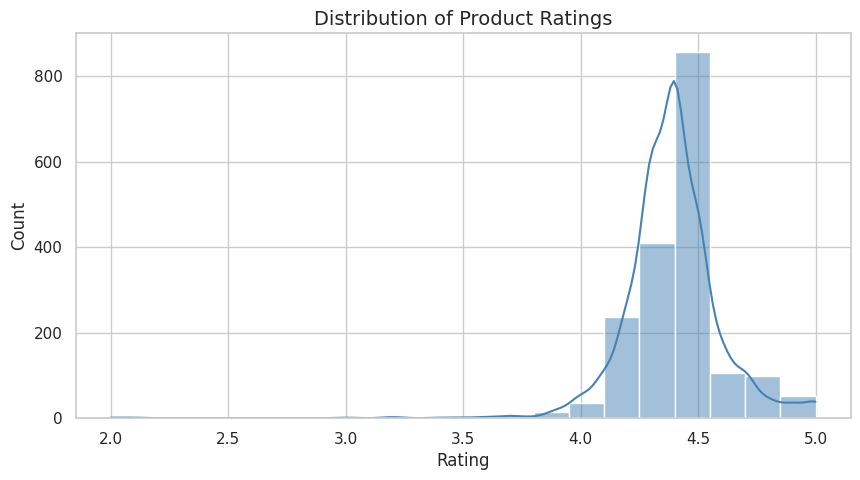

In [41]:
sns.histplot(nykaa1['rating'], bins=20, kde=True, color='steelblue')
plt.xlabel('Rating')
plt.title('Distribution of Product Ratings')
plt.show()

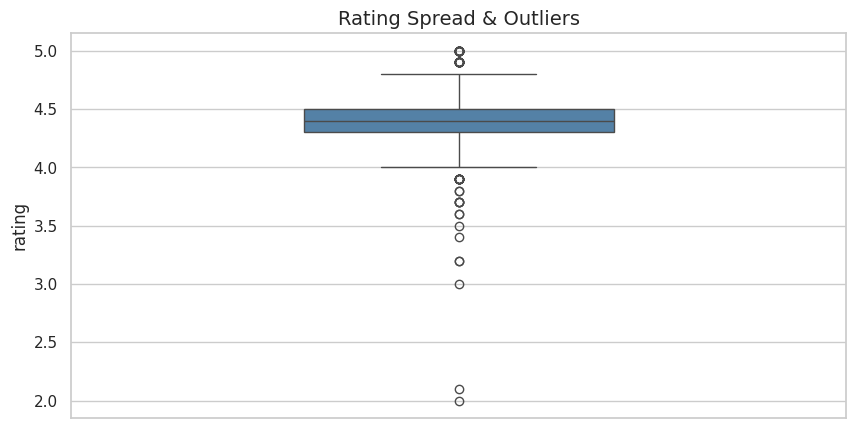

In [42]:
sns.boxplot(y=nykaa1['rating'], color='steelblue', width=0.4)
plt.title('Rating Spread & Outliers')
plt.show()

In [43]:
nykaa1['rating'].skew()

np.float64(-1.6247944310865843)

### Insight — Rating Distribution
* The distribution is left-skewed (skew ≈ -1.624), indicating that most products are concentrated in the higher rating range of 4.2–4.6.
* The median rating is around 4.4, with very few products rated below 4.0.
* A small number of outliers in the 2.0–3.0 range are visible in the boxplot, representing genuinely low-performing products.
* This reflects a rating inflation pattern commonly observed in e-commerce platforms, where poorly rated products are either delisted or receive fewer reviews, causing ratings to cluster at the higher end.

In [44]:
nykaa1['final_price'].describe()

,final_price
count,1827.000000
mean,1031.557745
std,1473.458050
min,44.000000
25%,336.000000
50%,529.000000
75%,1169.000000
max,15215.000000


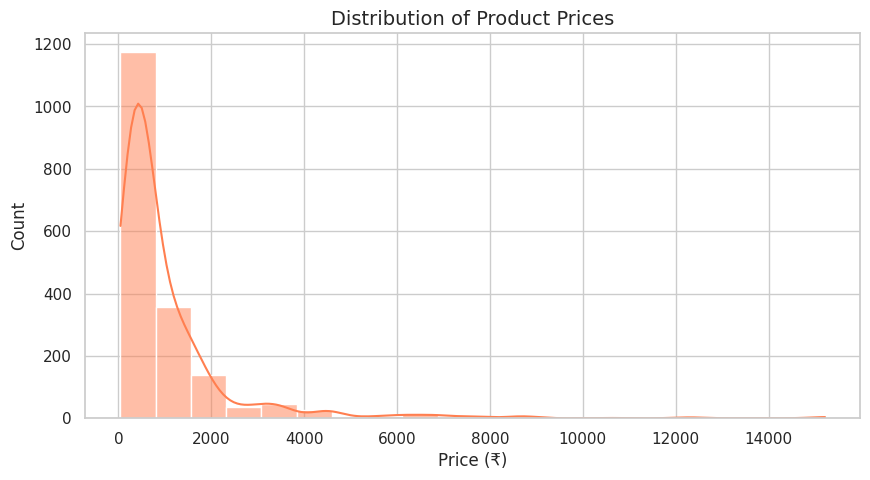

In [45]:
sns.histplot(nykaa1['final_price'], bins=20, kde=True, color='coral')
plt.xlabel('Price (₹)')
plt.title('Distribution of Product Prices')
plt.show()

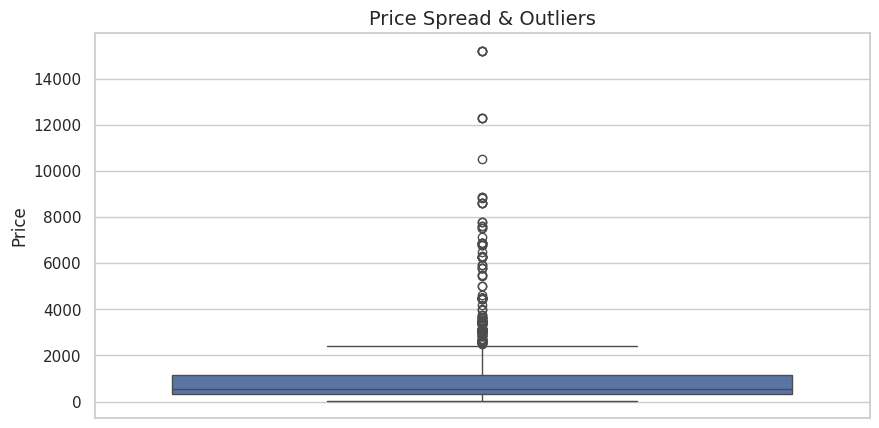

In [91]:
sns.boxplot(y=nykaa1['final_price'])

plt.ylabel('Price')
plt.title('Price Spread & Outliers')

plt.show()

In [47]:
nykaa1['final_price'].skew()

np.float64(4.609788639721847)

### Insight — Price Distribution

* Heavily right-skewed (skew = 4.61) — majority of products priced under ₹1000, with a long tail stretching to ₹15,000+
* Boxplot shows median well under ₹1000, and the extreme outliers are clearly luxury/premium products
- Median price is ₹529 while mean is ₹1032 — the gap of ~₹500 between
  these two confirms how heavily the luxury segment pulls the average up,
  making median a more honest representation of what a typical
  Nykaa customer actually pays.
- Price range is extreme — cheapest product at ₹44, most expensive
  at ₹15,215 — a 345x difference within the same platform.
- 75% of products are priced under ₹1169, confirming mass-market
  dominance with only the top 25% entering premium territory.

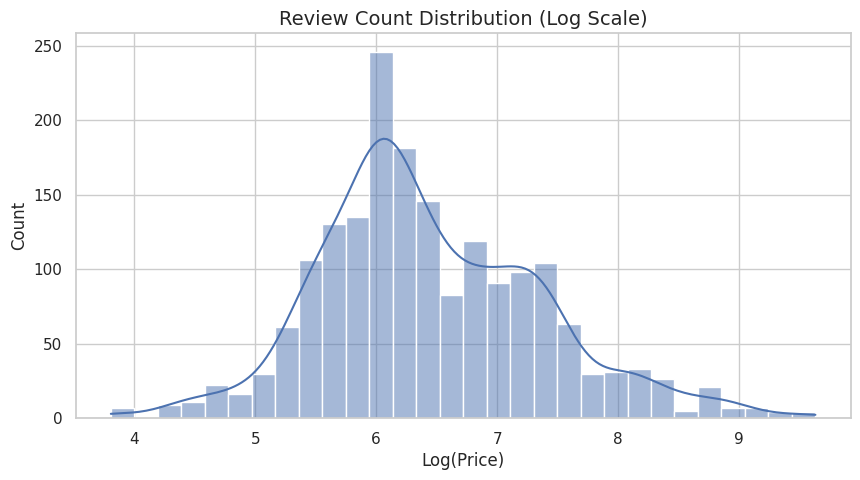

In [93]:
sns.histplot(np.log1p(nykaa1['final_price']), bins=30, kde=True)

plt.xlabel('Log(Price)')
plt.title('Review Count Distribution (Log Scale)')

plt.show()

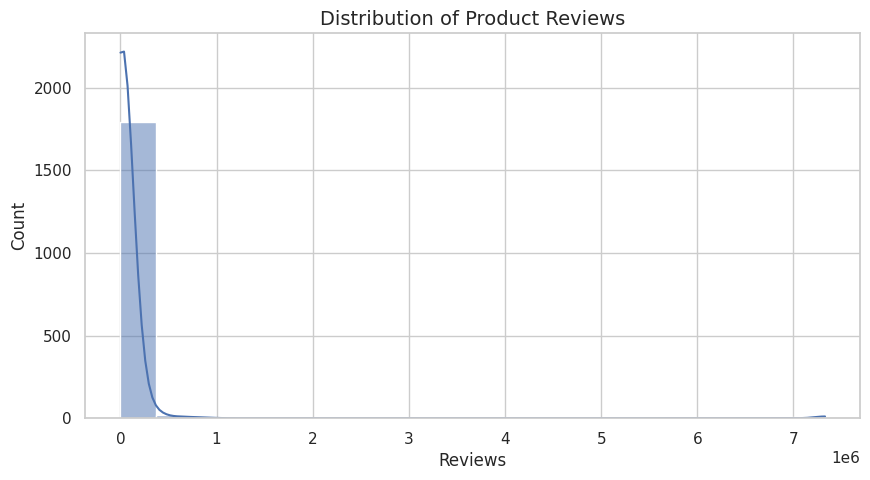

In [94]:
sns.histplot(nykaa1['review_count'], bins=20, kde=True)

plt.xlabel('Reviews')
plt.title('Distribution of Product Reviews')

plt.show()

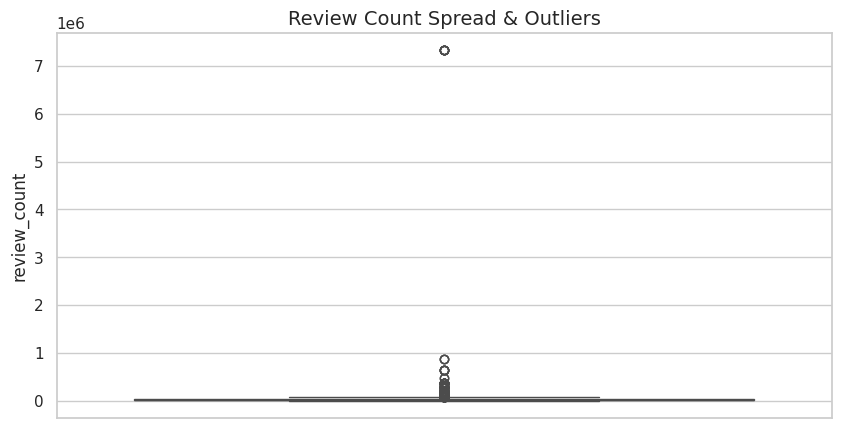

In [95]:
sns.boxplot(y=nykaa1['review_count'])

plt.ylabel('review_count')
plt.title('Review Count Spread & Outliers')

plt.show()

In [51]:
nykaa1['review_count'].skew()

np.float64(14.480401740007474)

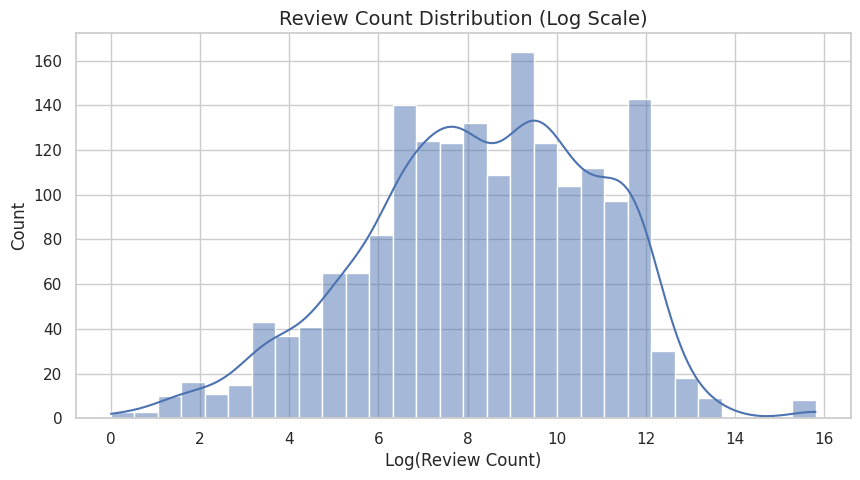

In [97]:
sns.histplot(np.log1p(nykaa1['review_count']), bins=30, kde=True)

plt.xlabel('Log(Review Count)')
plt.title('Review Count Distribution (Log Scale)')

plt.show()

### Insight — Review Count Distribution

* Skew = 14.48 — one of the most skewed distributions possible
* Nearly all products have very few reviews, but one outlier has 7.3M — likely a Nykaa bestseller that's been on the platform for years
* The boxplot median is basically at 0 on this scale — majority of products are relatively new or niche
* On log scale it shows a roughly normal distribution centered around log(6–8), meaning most products have between ~400–3000 reviews.(log(400) = 5.99,
log(3000) = 8.00)
- The isolated outlier at log(16) = 7.3M reviews is a data quality
  concern and should be excluded from any review-count-based analysis

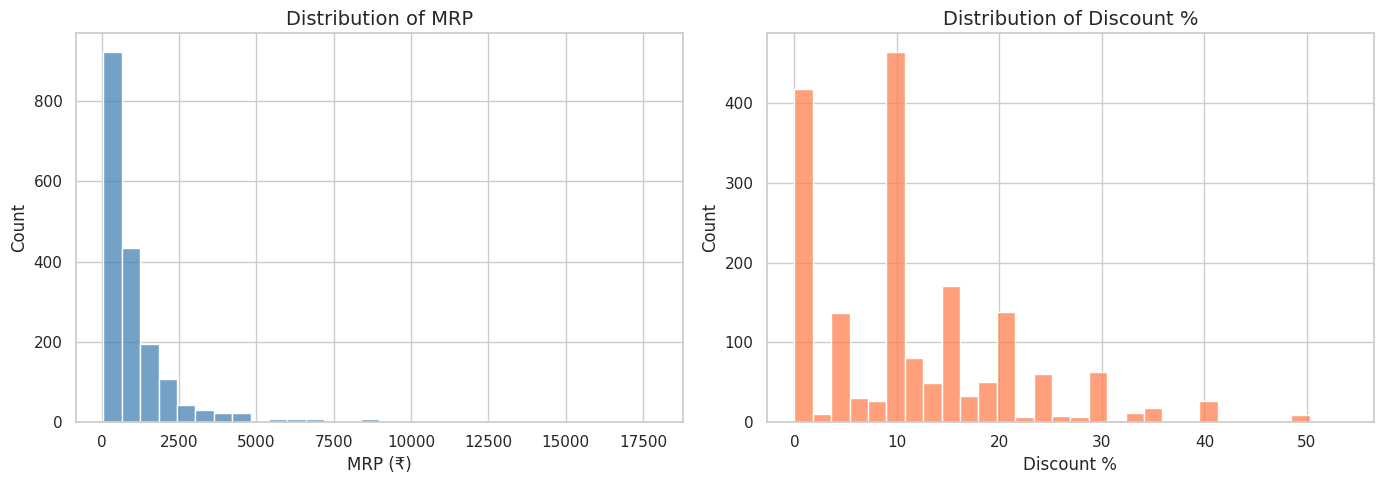

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(nykaa1['mrp'], bins=30, color='steelblue', ax=axes[0])
axes[0].set_xlabel('MRP (₹)')
axes[0].set_title('Distribution of MRP')

sns.histplot(nykaa1['discount_pct'], bins=30, color='coral', ax=axes[1])
axes[1].set_xlabel('Discount %')
axes[1].set_title('Distribution of Discount %')

plt.tight_layout()
plt.show()

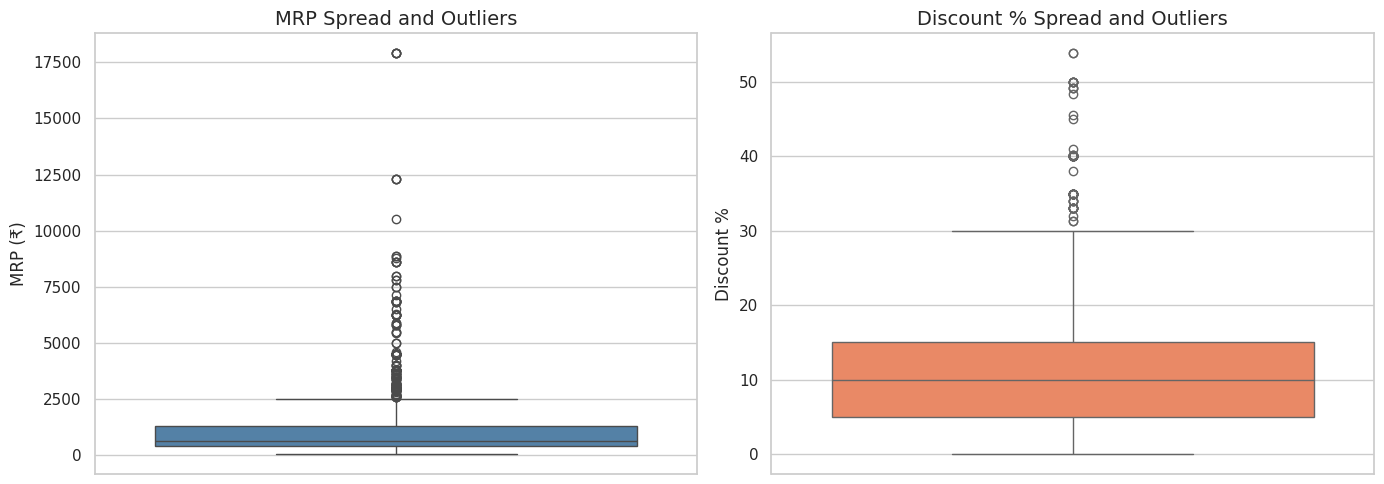

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(nykaa1['mrp'], color='steelblue', ax=axes[0])
axes[0].set_ylabel('MRP (₹)')
axes[0].set_title('MRP Spread and Outliers')

sns.boxplot(nykaa1['discount_pct'], color='coral', ax=axes[1])
axes[1].set_ylabel('Discount %')
axes[1].set_title('Discount % Spread and Outliers')

plt.tight_layout()
plt.show()

In [55]:
print(
    nykaa1['mrp'].skew(),
    nykaa1['discount_pct'].skew()
)

5.055593980103469 1.0673411031975417


### Insight - MRP and Discount
* MRP — Right-skewed similar to final price, with most products in lower price ranges and a long luxury tail up to ₹17,500.
*  Discount % — median is 10%, IQR between 5–15%, meaning
  half of all products are discounted between 5–15% only;
  heavy discounts (30%+) are rare outliers not standard practice
-  The two peaks in Discount % histogram (at 0% and 10%) suggest
  Nykaa has two distinct pricing strategies — undiscounted
  premium products and standardized 10% promotional discounts

## Univariate Analysis (Categorical Columns)

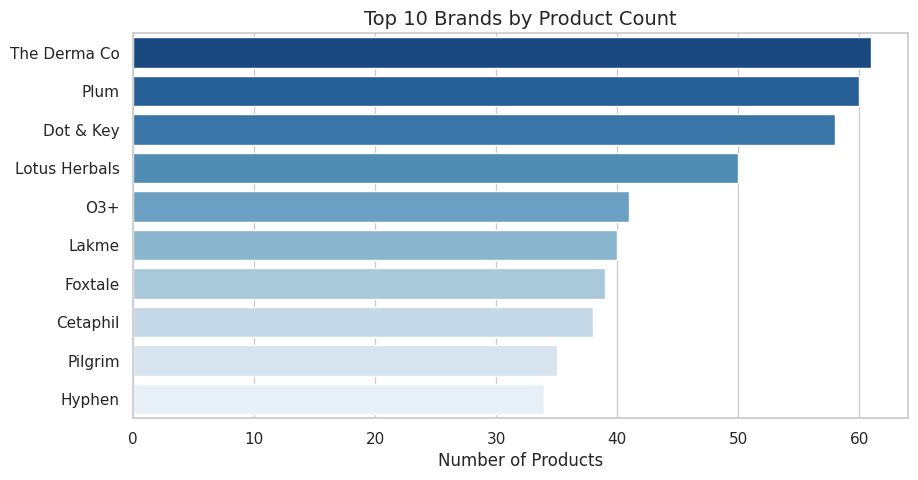

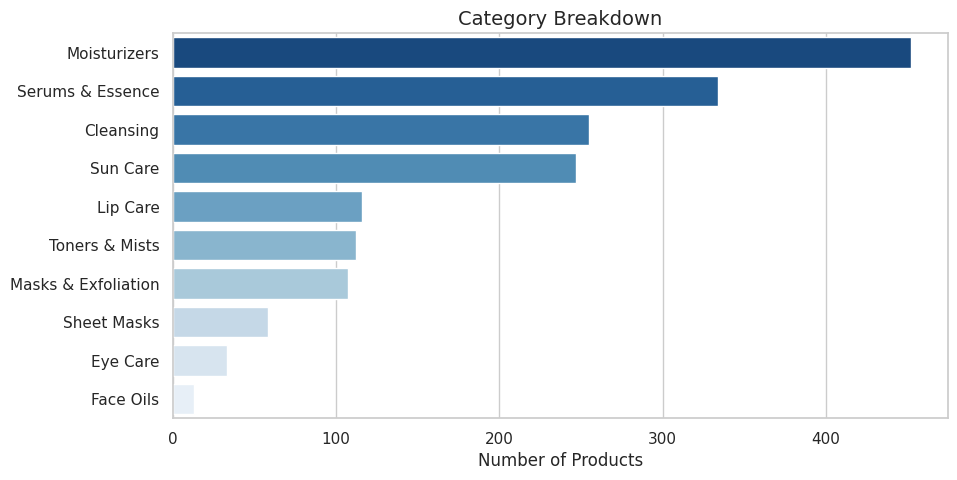

In [99]:
# Brand chart
top10 = nykaa1['brand'].value_counts().head(10).reset_index()
top10.columns = ['brand', 'count']

sns.barplot(data=top10, x='count', y='brand', hue='brand', palette='Blues_r', legend=False)
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('')
plt.show()

# Category chart
cat_counts = nykaa1[nykaa1['category_l3'].notna()]['category_l3'].value_counts().reset_index()
cat_counts.columns = ['category', 'count']

sns.barplot(data=cat_counts, x='count', y='category', hue='category', palette='Blues_r', legend=False)
plt.title('Category Breakdown')
plt.xlabel('Number of Products')
plt.ylabel('')
plt.show()

### Insight — Top 10 Brands

- The Derma Co and Plum are tied at the top (*~61 each*),
  followed by Dot & Key (*~59*) — no single brand dominates,
  the top 3 are extremely close
- Hyphen is the newest/smallest brand in top 10 (*~33 products*)
  — still establishing catalogue depth

### Insight — Category Breakdown
- Moisturizers (*~452*) and Serums & Essence (*~334*) dominate —
  together nearly 43% of the catalogue
- Cleansing (*~255*) and Sun Care (*~247*) are close in size —
  both are daily-use essentials driving volume
- Face Oils (13) and Eye Care (33) are the thinnest —
  findings from these treated as directional only
- Sheet Masks (58) is notably small despite being a popular
  format — may indicate underpenetration opportunity on Nykaa

## Bivariate Analysis (Numerical-Numerical)

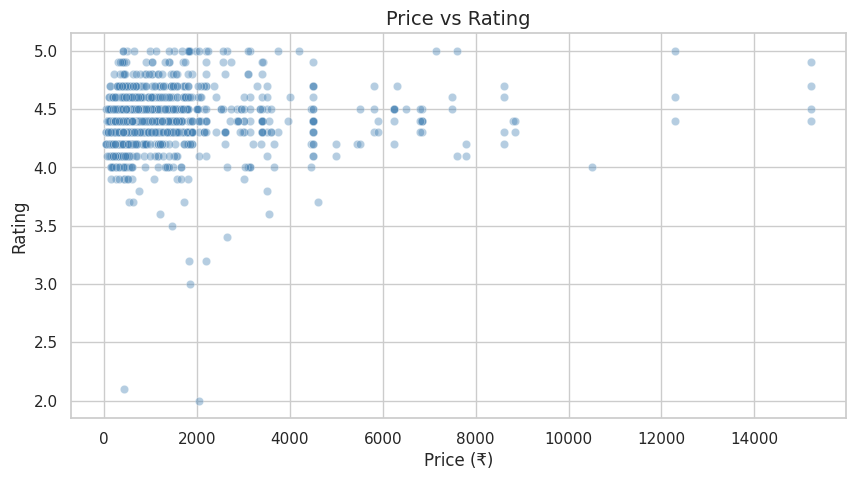

In [100]:
sns.scatterplot(data=nykaa1, x='final_price', y='rating', alpha=0.4, color='steelblue')
plt.xlabel('Price (₹)')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()

In [58]:
nykaa1['final_price'].corr(nykaa1['rating'])

np.float64(0.10197297724792474)

### Insight — Price vs Rating

* The correlation (*~0.10*) shows a very weak positive relationship between price and rating, meaning higher-priced products are only slightly (and insignificantly) associated with better ratings.
* The dense cluster on the left confirms most products are budget-priced and rated 4.0–4.7
- Price does not predict quality on Nykaa — this means buyers
  overpaying for premium products are not getting better-rated
  products; and budget buyers are not sacrificing quality.
  A ₹300 product is just as likely to be rated 4.5 as a ₹3000 one.

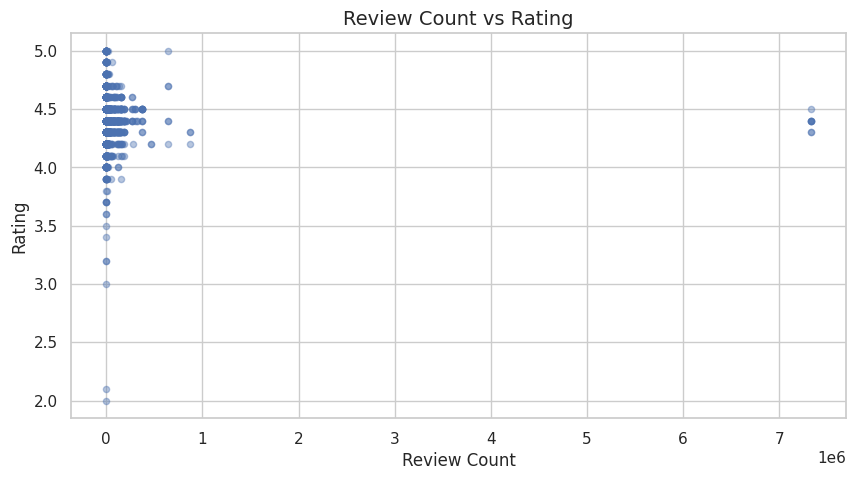

0.0026054493172636885


In [59]:
nykaa1.plot(kind='scatter', x='review_count', y='rating', alpha=0.4)
plt.xlabel('Review Count')
plt.ylabel('Rating')
plt.title('Review Count vs Rating')
plt.show()

print(nykaa1['review_count'].corr(nykaa1['rating']))

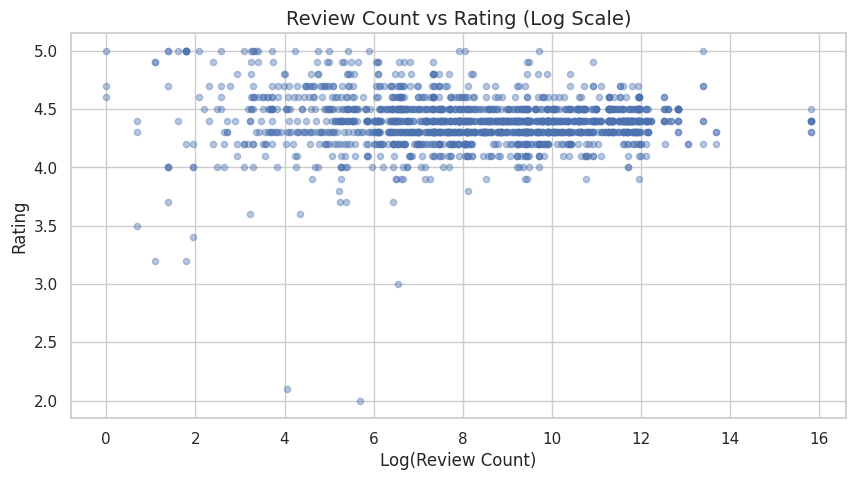

In [101]:
nykaa1.assign(log_reviews=np.log1p(nykaa1['review_count'])).plot(kind='scatter', x='log_reviews', y='rating', alpha=0.4)
plt.xlabel('Log(Review Count)')
plt.ylabel('Rating')
plt.title('Review Count vs Rating (Log Scale)')
plt.show()

### Insight — Review Count vs Rating

* Correlation = 0.0026 — essentially zero relationship
* Raw scatter is dominated by the 7.3M outlier making everything else unreadable
* Log scale scatter shows the real picture — ratings are uniformly spread across all review count levels, no trend whatsoever
* Popularity does not equal quality on Nykaa

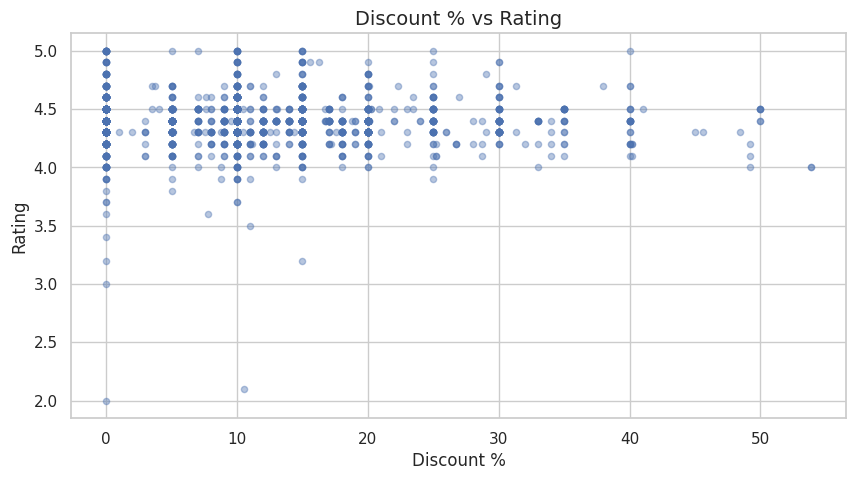

-0.00486599394601278


In [61]:
nykaa1.plot(kind='scatter', x='discount_pct', y='rating', alpha=0.4)
plt.xlabel('Discount %')
plt.ylabel('Rating')
plt.title('Discount % vs Rating')
plt.show()

print(nykaa1['discount_pct'].corr(nykaa1['rating']))

### Insight — Discount % vs Rating

* The correlation (*~-0.0049*) indicates almost no relationship between discount percentage and product rating.
* Heavily discounted products (60–80%) are sparse and don't show consistently lower ratings
* Discounting on Nykaa is driven by promotions rather than poor product performance.

## Bivariate Analysis (Numerical-Categorical)

All category-level analyses in this section use a filtered
dataset excluding unmapped categories (NaN values in category_l3).
```python
cat_data = nykaa1[nykaa1['category_l3'].notna()]
```
The full dataset (nykaa1) contains ~100 rows where category_l3
is NaN — these are products from dropped categories.

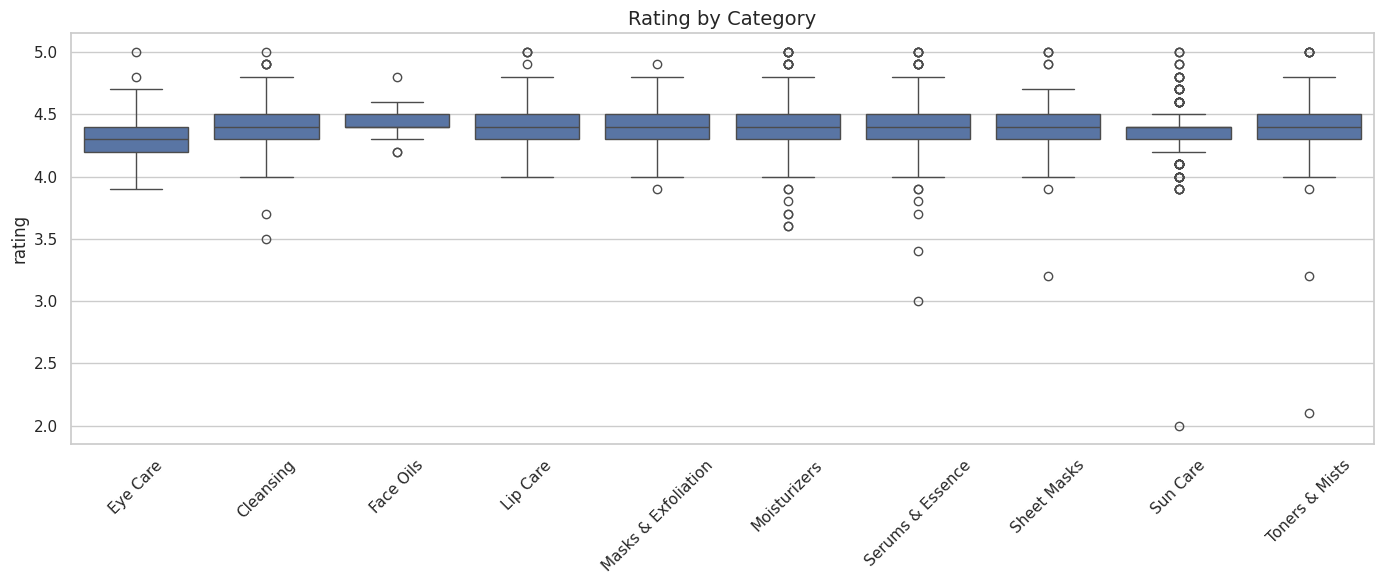

In [62]:
cat_data = nykaa1[nykaa1['category_l3'].notna()]

plt.figure(figsize=(14, 6))
order = cat_data.groupby('category_l3')['rating'].median().sort_values().index
sns.boxplot(data=cat_data, x='category_l3', y='rating', order=order)
plt.xticks(rotation=45)
plt.title('Rating by Category')
plt.xlabel('')
plt.tight_layout()
plt.show()

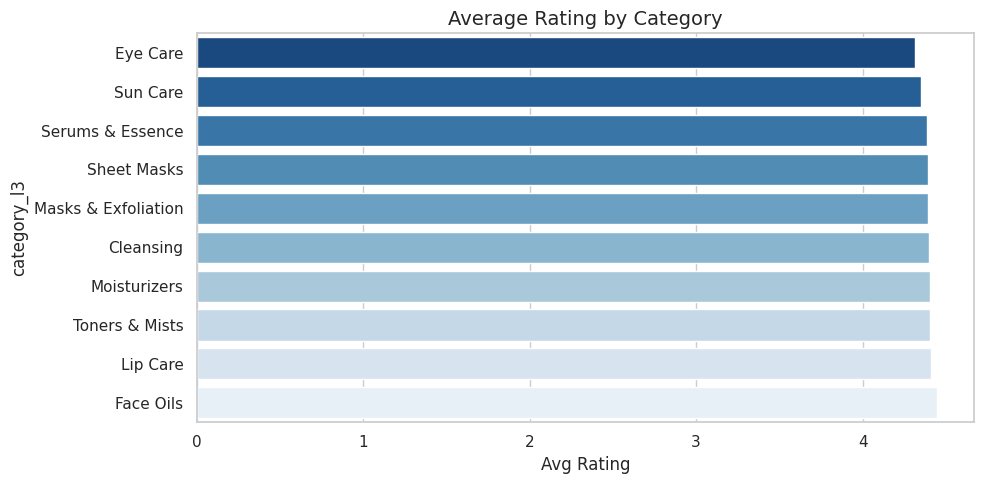

In [63]:
avg_rating = cat_data.groupby('category_l3')['rating'].mean().sort_values().reset_index()

sns.barplot(data=avg_rating, x='rating', y='category_l3', hue='category_l3', palette='Blues_r', legend=False)
plt.xlabel('Avg Rating')
plt.title('Average Rating by Category')
plt.tight_layout()
plt.show()

### Insight — Rating by Category

### Insight — Rating by Category  

**Boxplot observations:**  
- Most categories have similar median ratings (~4.3–4.5), indicating overall rating inflation.  
- Sun Care shows the highest variability with some low-rated outliers.  
- Eye Care has several low outliers despite a high average, suggesting inconsistency.  
- Toners & Mists show moderate variation with both high and low outliers.  
- Face Oils and Lip Care are the most consistent categories.  

**Average rating observations:**  
- Eye Care has the highest average (~4.5), likely influenced by a small sample size.  
- Face Oils has the lowest average (~4.3), also based on limited data.  
- The overall difference across categories is minimal (~0.2), showing little real variation.  

**Key takeaway:**  
Category is not a strong indicator of product quality, as ratings are similar across all categories.

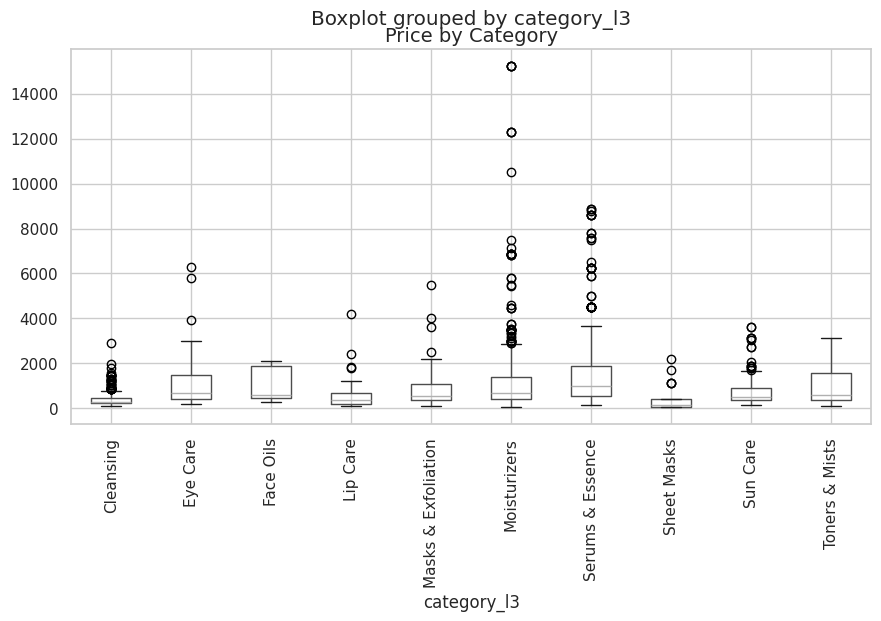

In [102]:
nykaa1.boxplot(column='final_price', by='category_l3', rot=90)
plt.title('Price by Category')
plt.show()

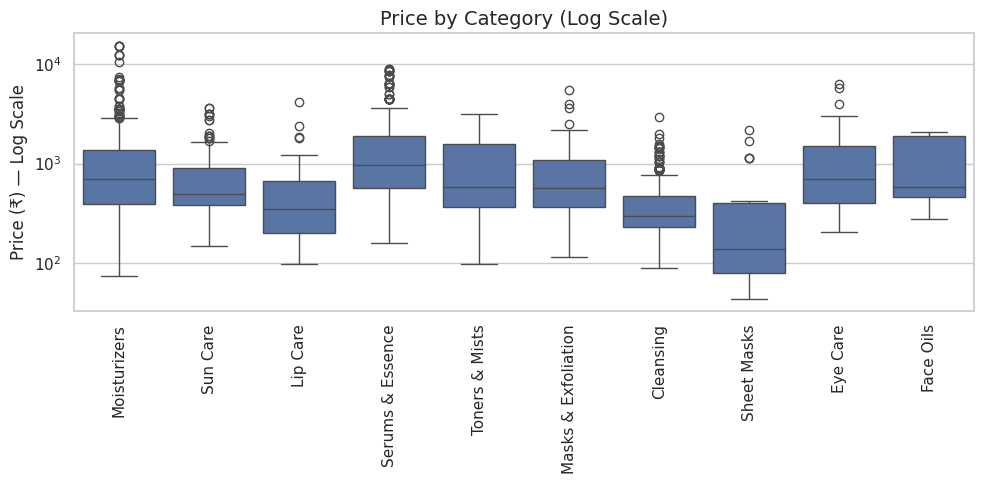

In [104]:
order = cat_data.groupby('category_l3')['final_price'].median().sort_values().index
sns.boxplot(data=cat_data, x='category_l3', y='final_price')
plt.xticks(rotation=90)
plt.yscale('log')  # log scale removes outlier distortion
plt.title('Price by Category (Log Scale)')
plt.xlabel('')
plt.ylabel('Price (₹) — Log Scale')
plt.tight_layout()
plt.show()

### Insight — Price by Category

- Moisturizers have the widest price range and highest outliers
  (up to ₹15,000) — the most premium-heavy category on Nykaa
- Serums & Essence have the highest IQR — premium positioning
  is concentrated here, serums are where brands charge more
- Sheet Masks and Cleansing are tightly priced and budget-friendly
  — commodity categories with little price variation
- Eye Care and Face Oils show moderate outliers despite small
  samples — niche premium products exist in both
- Across all categories medians sit under ₹1000 — mass market
  dominates everywhere, premium is always the exception
- Sun Care is surprisingly affordable given its growth —
  median under ₹500, opportunity for premium SPF brands to enter

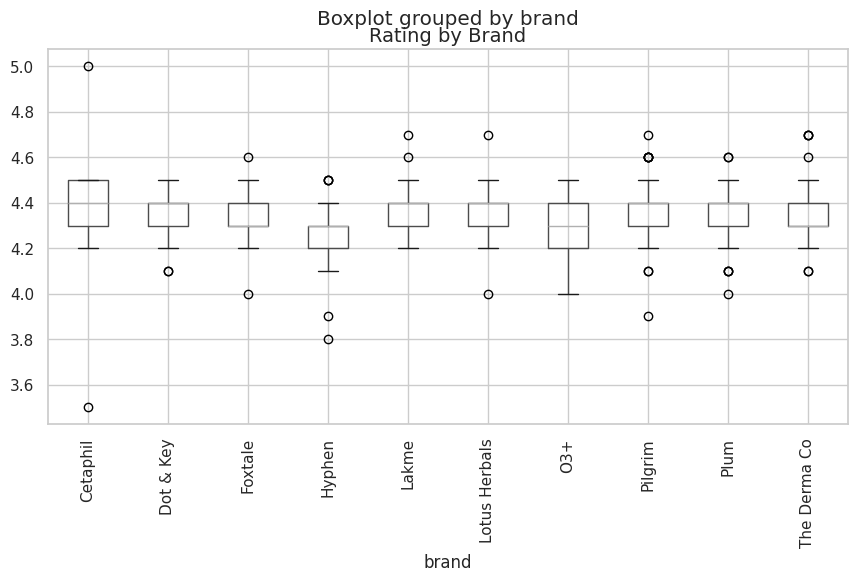

In [66]:
top10_brands = nykaa1['brand'].value_counts().head(10).index
nykaa1[nykaa1['brand'].isin(top10_brands)].boxplot(column='rating', by='brand', rot=90)
plt.title('Rating by Brand')
plt.show()

### Insight — Rating by Brand

- Plum and Foxtale have the tightest boxes — most consistent
  brands in the top 10, rarely produce low-rated products
- Hyphen has the lowest median (~4.2) and outliers down to 3.8
  — weakest performer in the top 10 despite being a newer brand
- Cetaphil has an outlier at 3.6 — one notably weak product
  dragging down an otherwise consistent brand
- Lakme shows outliers both high (4.7) and low (3.8) —
  inconsistent quality across its wide product range
- All brands operate in a narrow 4.2–4.5 band — no brand
  dramatically outperforms another, confirming platform-wide
  rating compression
- The Derma Co is the largest brand by product count but sits
  mid-table on rating consistency — scale hasn't translated
  to quality differentiation

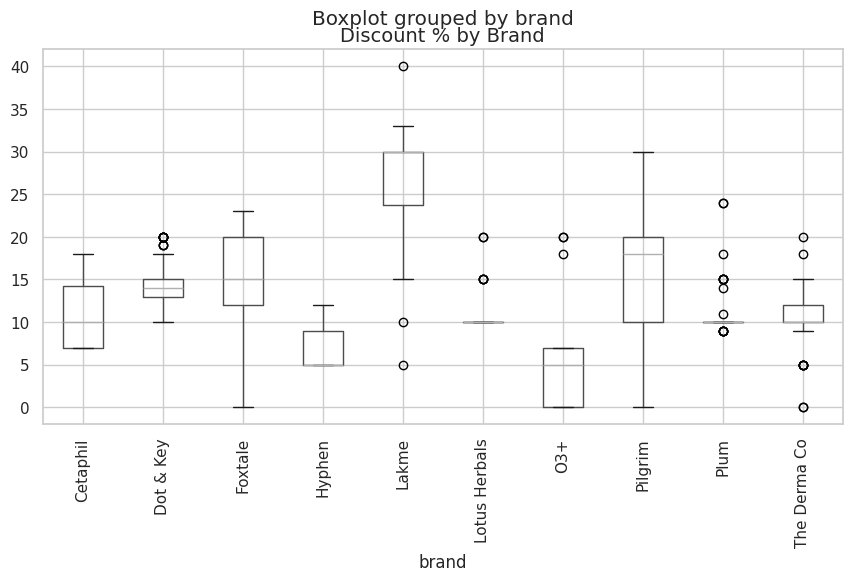

In [67]:
nykaa1[nykaa1['brand'].isin(top10_brands)].boxplot(column='discount_pct', by='brand', rot=90)
plt.title('Discount % by Brand')
plt.show()


### Insight — Discount % by Brand

- Lakme has the highest median discount (~25%) and widest
  spread (up to 40%) — most aggressive discounting brand,
  classic mass market promotional strategy
- Pilgrim also discounts heavily (median ~18%, wide spread)
  — D2C brand using discounts as customer acquisition tool
- O3+ has the lowest median (~5%) with minimal spread —
  controlled pricing, closer to premium/pharma positioning
- Hyphen shows tight low discounts (~7%) — new brand but
  maintaining price integrity
- Foxtale and The Derma Co sit in the middle (~10–15%) —
  moderate promotional discounting
- Dot & Key and Cetaphil are consistent around 13–15% —
  standardized discount strategy
- Plum has the most outliers — inconsistent discounting
  across its product range, no clear pricing strategy

**Key takeaway:**
Discount strategy clearly separates brand archetypes —
legacy mass brands (Lakme) compete on price promotions
while newer D2C and pharma-adjacent brands (O3+, Hyphen)
protect price integrity to signal quality.

## Bivariate Analysis (Categorical-Categorical)

In [68]:
ct1 = pd.crosstab(nykaa1['brand'].where(nykaa1['brand'].isin(top10_brands)), nykaa1['category_l3'])
ct1


category_l3,Cleansing,Eye Care,Lip Care,Masks & Exfoliation,Moisturizers,Serums & Essence,Sheet Masks,Sun Care,Toners & Mists
brand,,,,,,,,,
Cetaphil,18,1,0,0,7,6,0,2,1
Dot & Key,10,2,4,2,12,7,0,17,3
Foxtale,5,1,2,5,7,9,0,8,2
Hyphen,3,0,8,2,3,11,0,6,1
Lakme,3,0,1,0,18,6,2,10,0
Lotus Herbals,4,0,0,1,30,0,0,8,1
O3+,5,1,0,11,4,3,4,2,0
Pilgrim,5,1,0,3,10,9,0,4,2
Plum,9,1,2,0,12,13,0,7,11


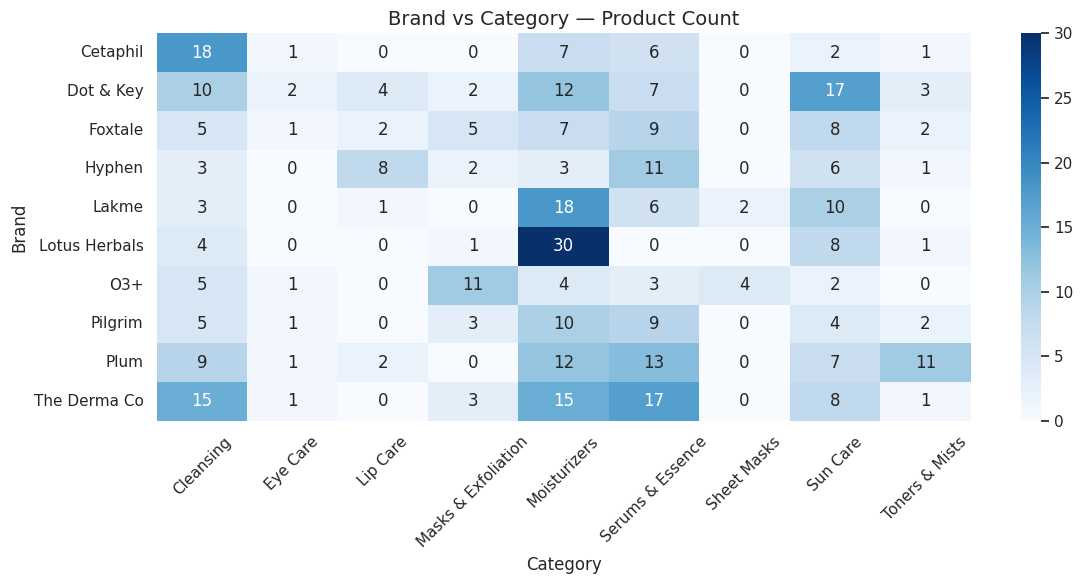

In [69]:
plt.figure(figsize=(12, 6))
sns.heatmap(ct1, annot=True, cmap='Blues',   )
plt.title('Brand vs Category — Product Count')
plt.xlabel('Category')
plt.ylabel('Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight — Brand vs Category

- Lotus Herbals is almost entirely Moisturizers (30/44 products)
  — single category dominance, legacy cream brand with no
  meaningful presence in serums or treatments
- Cetaphil leads Cleansing (18) — strongest cleansing brand
  in top 10, consistent with its derma/pharma positioning
- Dot & Key leads Sun Care (17) — clear SPF category ownership,
  reflects their marketing identity
- The Derma Co is most diversified — Cleansing (15),
  Moisturizers (15), Serums (17) — true full portfolio strategy
- O3+ uniquely owns Masks & Exfoliation (11) — no other brand
  concentrates here, clear white space ownership
- Hyphen is serum-heavy (11 serums out of 34 total) —
  ingredient-led positioning despite being a newer brand
- Plum has the most balanced spread — Serums (13),
  Moisturizers (12), Toners (11) — genuine multi-category brand
- Sheet Masks column is all zeros or near-zero across every
  brand — no top brand owns this category,
  significant white space opportunity

## Ingredients Analysis

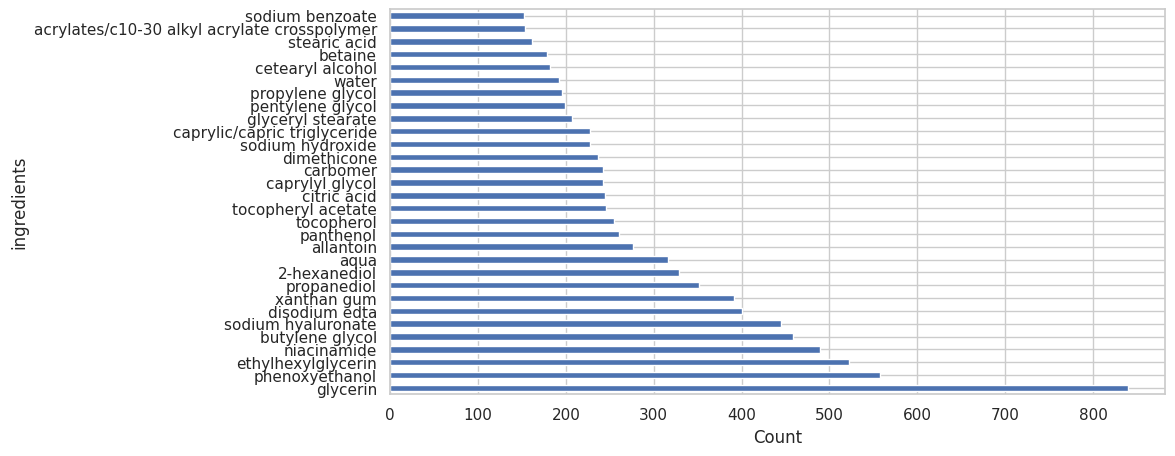

In [70]:
exploded = nykaa1['ingredients'].explode()
exploded.value_counts().head(30).plot(kind='barh')
plt.xlabel('Count')
plt.show()

#### Cleaning
* 'Aqua' and 'water' likely refer to the same ingredient but appear as separate entries

In [71]:
nykaa1['ingredients'] = nykaa1['ingredients'].apply(
    lambda x: ['water' if i == 'aqua' else i for i in x]
)

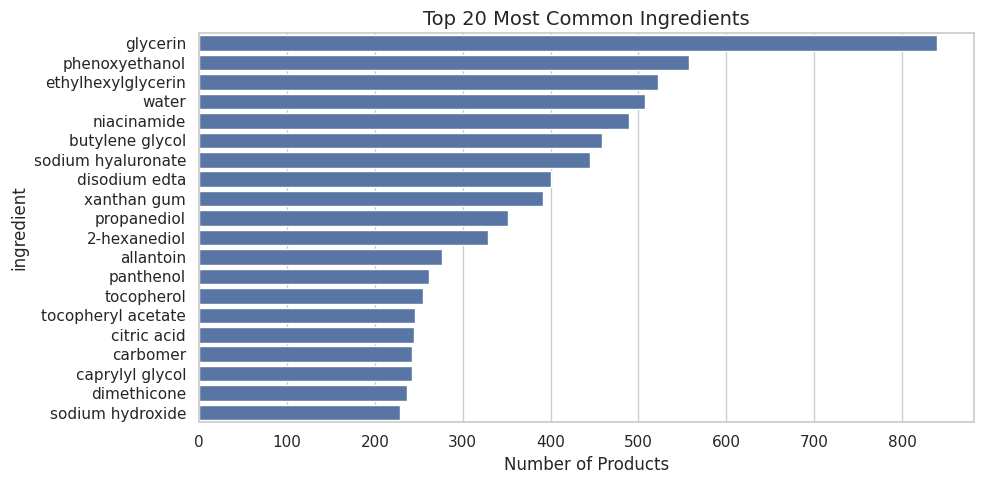

In [72]:
exploded = nykaa1['ingredients'].explode()
ing_counts = exploded.value_counts().head(20).reset_index()
ing_counts.columns = ['ingredient', 'count']

sns.barplot(data=ing_counts, x='count', y='ingredient')
plt.xlabel('Number of Products')
plt.title('Top 20 Most Common Ingredients')
plt.tight_layout()
plt.show()

### Insight — Top 20 Most Common Ingredients

- Glycerin dominates (~820 products) — appears in almost
  every product as a base humectant, universal across all
  price points and categories
- Phenoxyethanol (*~500*) and Ethylhexylglycerin (~480) are
  the most common preservative pair — nearly always used
  together, industry standard combination
- Niacinamide (~460) ranking this high for an active
  ingredient is remarkable — reflects the massive niacinamide
  trend in Indian skincare, now essentially a baseline
  ingredient rather than a premium active
- Water (~450) acts as the primary solvent — lower than
  glycerin because some anhydrous products (oils, balms)
  don't contain water
- Sodium hyaluronate (~420) vs hyaluronic acid — the salt
  form dominates because it penetrates skin more effectively,
  brands have shifted formulation preferences
- Most ingredients from rank 8 onwards are base formulation
  ingredients — emulsifiers, stabilizers, thickeners —
  confirming that the top actives are glycerin,
  niacinamide and sodium hyaluronate


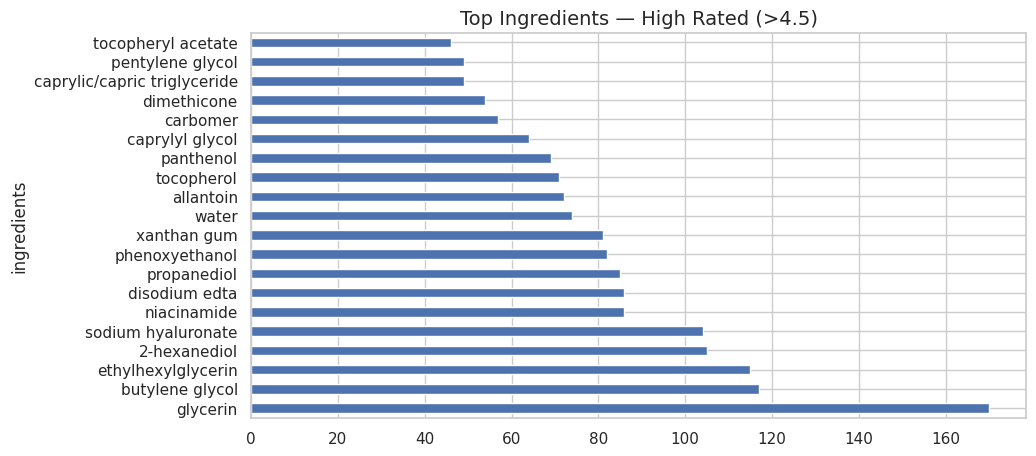

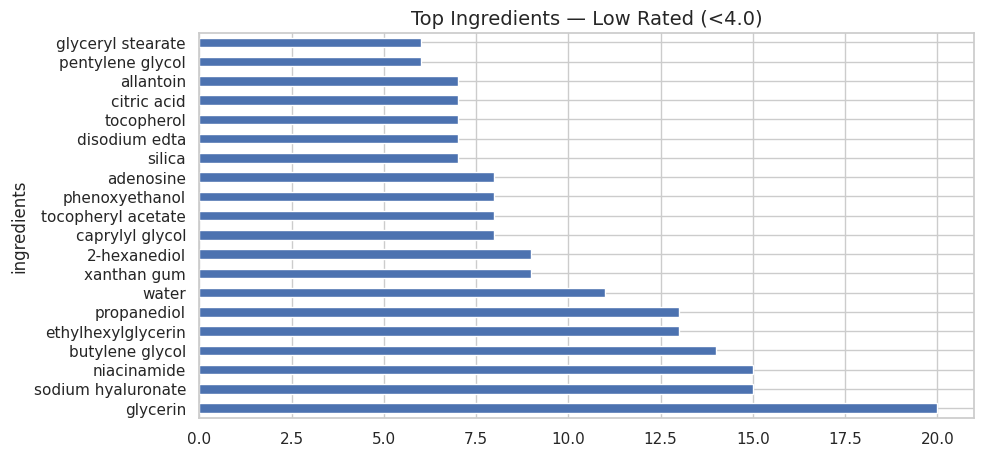

High rated products: 258
Low rated products: 28


In [73]:
high_rated = nykaa1[nykaa1['rating'] > 4.5]
low_rated = nykaa1[nykaa1['rating'] < 4.0]

high_ings = high_rated['ingredients'].explode().value_counts().head(20)
low_ings = low_rated['ingredients'].explode().value_counts().head(20)

high_ings.plot(kind='barh')
plt.title('Top Ingredients — High Rated (>4.5)')
plt.show()

low_ings.plot(kind='barh')
plt.title('Top Ingredients — Low Rated (<4.0)')
plt.show()

print("High rated products:", high_rated.shape[0])
print("Low rated products:", low_rated.shape[0])

### Insight — High vs Low Rated Ingredients

- High rated (n=258) and low rated (n=28) top ingredients
  are almost identical — glycerin, niacinamide, sodium
  hyaluronate, butylene glycol dominate both lists
- No clear "bad" ingredient signal exists — the same
  base formulation appears regardless of rating
- Niacinamide and sodium hyaluronate appear prominently
  in BOTH — confirms these are universal ingredients,
  not quality differentiators
- Adenosine appears in low-rated top 20 but not high-rated
  — directional observation only given small sample
- Silica appears in low-rated — texture agent associated
  with mattifying products, may indicate formula type
  rather than quality issue

**Limitation:** With only 28 low-rated products (1.5% of
dataset) no statistically reliable red-flag ingredients
can be identified. A minimum of n=100 low-rated products
would be needed for meaningful comparison. This analysis
is directional only.


>  rating < 4.0  →   28 products  (1.5%)<br>
   4.0 - 4.5     → 1541 products  (84.3%)  ← bulk of dataset<br>
   rating > 4.5  →  258 products  (14.1%)
  

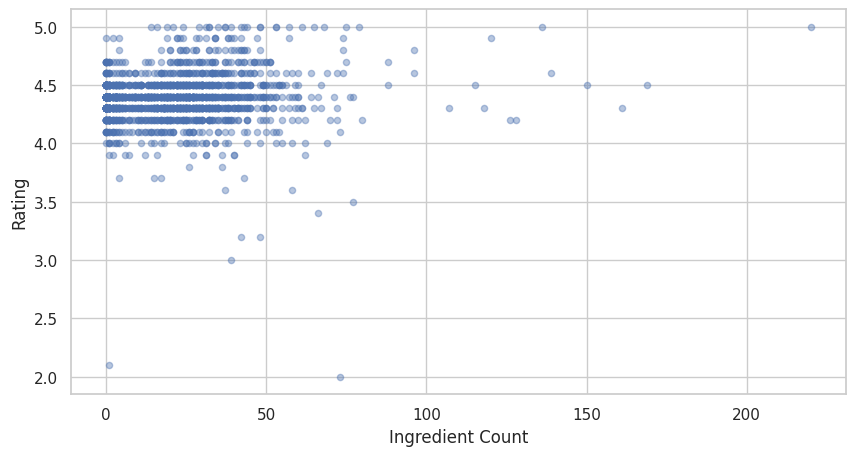

0.1159822491719004


In [74]:
nykaa1['ing_count'] = nykaa1['ingredients'].apply(len)
nykaa1.plot(kind='scatter', x='ing_count', y='rating', alpha=0.4)
plt.xlabel('Ingredient Count')
plt.ylabel('Rating')
plt.show()

print(nykaa1['ing_count'].corr(nykaa1['rating']))

### Insight — Ingredient Count vs Rating
* More ingredients don't mean better ratings (correlation = 0.115) — a simple 15-ingredient product is just as likely to be highly rated as a complex 80-ingredient one.
- This has a clear PM implication — consumers cannot detect
  formulation complexity through ratings alone; marketing
  and brand trust drive perception more than actual formula

In [75]:
budget = nykaa1[nykaa1['final_price'] < 300]
premium = nykaa1[nykaa1['final_price'] > 1500]

budget_ings = budget['ingredients'].explode().value_counts().head(15)
premium_ings = premium['ingredients'].explode().value_counts().head(15)

print("Budget products:", budget.shape[0])
print("Premium products", premium.shape[0])

Budget products: 380
Premium products 305


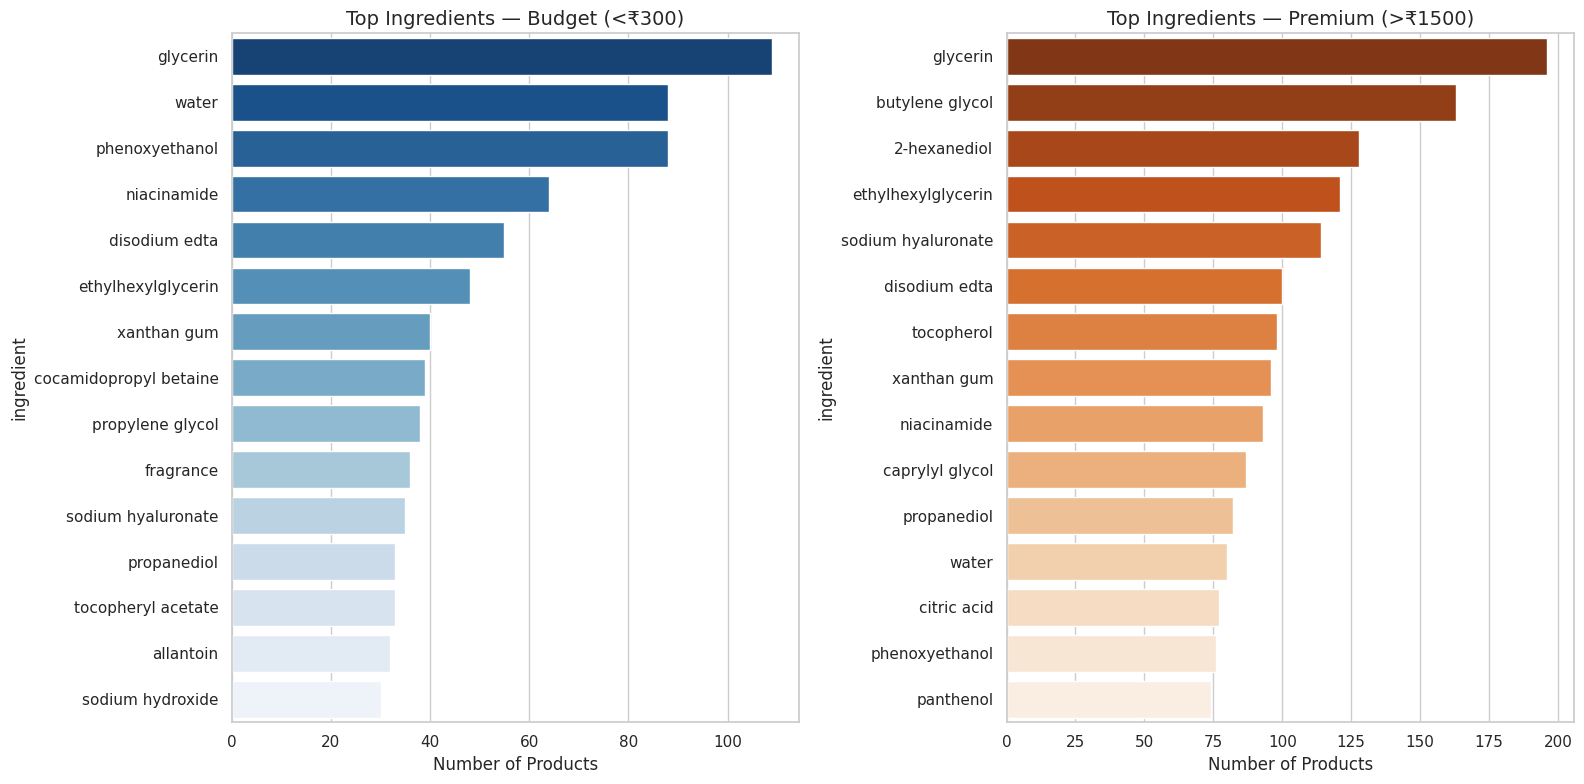

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

budget_df = budget_ings.reset_index()
budget_df.columns = ['ingredient', 'count']
sns.barplot(data=budget_df, x='count', y='ingredient',
            hue='ingredient', palette='Blues_r', legend=False, ax=ax1)
ax1.set_title('Top Ingredients — Budget (<₹300)')
ax1.set_xlabel('Number of Products')

premium_df = premium_ings.reset_index()
premium_df.columns = ['ingredient', 'count']
sns.barplot(data=premium_df, x='count', y='ingredient',
            hue='ingredient', palette='Oranges_r', legend=False, ax=ax2)
ax2.set_title('Top Ingredients — Premium (>₹1500)')
ax2.set_xlabel('Number of Products')

plt.tight_layout()
plt.show()

### Insight — Budget vs Premium Ingredients

- Glycerin, phenoxyethanol, water are universal — appear
  at top of both lists regardless of price point
- Key difference — **Fragrance** appears in budget top 15
  but NOT in premium — budget brands use fragrance as a
  cheap sensory enhancer; premium brands avoid it
  (fragrance is a known irritant, sophisticated consumers
  avoid it)
- **Cocamidopropyl betaine** in budget — cheap surfactant
  used in mass market cleansers; absent in premium
- Premium uniquely shows **2-hexanediol** and **butylene
  glycol** higher up — more sophisticated humectant and
  solvent system
- **Tocopherol** (vitamin E) ranks higher in premium —
  antioxidant active, adds formulation cost
- Niacinamide appears in both — confirms it has become
  a commodity active, no longer a premium differentiator
- Base formulation is surprisingly similar — the real
  difference between budget and premium is a few
  performance actives and the absence of fragrance,
  not a completely different formula

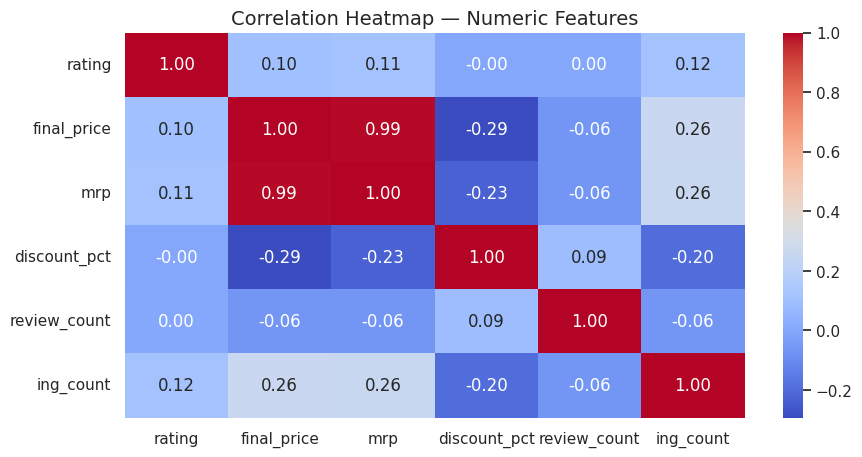

In [77]:
corr_cols = ['rating', 'final_price', 'mrp', 'discount_pct', 'review_count', 'ing_count']
corr_matrix = nykaa1[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

### Insight — Correlation Analysis of Key Features  

- Final Price and MRP are highly correlated (0.99), as expected.  
- Discount % is negatively correlated with price, indicating premium products are discounted less.  
- Rating shows near-zero correlation with all variables, suggesting it is independent of price, reviews, and discounts.  
- Ingredient count has a weak positive correlation with price, indicating slightly higher cost for complex products.  
- Review count has negligible correlation with other variables, showing popularity is independent of price and rating.  
- Discount % and ingredient count are weakly negatively correlated, meaning simpler products are discounted more.  

**Key takeaway:**  
No single factor reliably predicts product ratings. This highlights the need for a more robust metric, such as a credibility score combining rating and review count.

# Credibility Score

## Problem
Raw ratings on Nykaa are heavily inflated and compressed
— 84% of products sit between 4.0–4.5, making star rating
alone a poor signal for product quality.

A product with:
- 4.8 rating and 9 reviews → is this trustworthy?
- 4.6 rating and 8,000 reviews → clearly more reliable

Raw rating cannot distinguish between these two. We need
a better signal.

## Solution
Combine rating with review count into a single
**Credibility Score**:

`Credibility Score = rating × log(1 + review_count)`



In [106]:
nykaa1['credibility_score'] = (nykaa1['rating'] * np.log1p(nykaa1['review_count']))

print(nykaa1['credibility_score'].describe())

count       1827.0
mean       36.4245
std      11.647718
min            0.0
25%      28.936889
50%      36.879953
75%      44.992638
max      71.132429
Name: credibility_score, dtype: Float64


In [107]:
top_raw = nykaa1.nlargest(10, 'rating')[
    ['name', 'brand', 'rating', 'review_count', 'credibility_score']
]

top_cred = nykaa1.nlargest(10, 'credibility_score')[
    ['name', 'brand', 'rating', 'review_count', 'credibility_score']
]

print("Top 10 by Raw Rating")
print(top_raw[['name', 'brand', 'rating', 'review_count']].to_string())
print(" Top 10 by Credibility Score")
print(top_cred[['name', 'brand', 'rating', 'review_count']].to_string())

Top 10 by Raw Rating
                                                                                               name            brand  rating  review_count
1275                                                           Laneige Water Bank Aqua Facial Serum          LANEIGE     5.0             3
1304                                                   ISDIN Fotoprotector Transparent Spray SPF 50            ISDIN     5.0            26
1410                                                Ponds Ultra Light Biome Gel With Cera - Hyamino            Ponds     5.0        646538
1449                                                     Supergoop Mineral Mattescreen SPF 40 PA+++        Supergoop     5.0            40
1630                                              Medicube PDRN Pink Vita Coating Mask - pack of 10         Medicube     5.0             7
1651                    Eqqualberry Bakuchiol Plumping Serum – Niacinamide, Firming & Pore Refining      Eqqualberry     5.0             5
1739  

In [110]:
nykaa1['raw_rank'] = nykaa1['rating'].rank(ascending=False)
nykaa1['cred_rank'] = nykaa1['credibility_score'].rank(ascending=False)
nykaa1['rank_change'] = nykaa1['raw_rank'] - nykaa1['cred_rank']

# Products that drop most when using credibility score
biggest_losers = nykaa1.nsmallest(10, 'rank_change')[
    ['name', 'brand', 'rating', 'review_count', 'credibility_score', 'rank_change']
]

print("Products that LOSE rank with credibility score")
print("(High rating but very few reviews)")
print(biggest_losers[['name', 'brand', 'rating', 'review_count']].to_string())

Products that LOSE rank with credibility score
(High rating but very few reviews)
                                                                                                 name            brand  rating  review_count
1829    d'Alba piedmont Waterfull Essence Sun Cream, Vegan Lightweight, Broad Spectrum SPF 50+, Glowy  d'Alba Piedmont     5.0             0
1275                                                             Laneige Water Bank Aqua Facial Serum          LANEIGE     5.0             3
2186                                                                Bobbi Brown Extra Lip Tinted Balm      Bobbi Brown     5.0             3
2510  Cetaphil Healthy Renew Micellar Cleanser, Triple Action Formula for Anti Aging Skincare Routine         Cetaphil     5.0             4
1651                      Eqqualberry Bakuchiol Plumping Serum – Niacinamide, Firming & Pore Refining      Eqqualberry     5.0             5
1739                                                  Anua Azelaic 10 + 

# Business Insights
* Best value brands — high rating, low price
* Most reviewed categories
* Data driven skincare routine under ₹1500



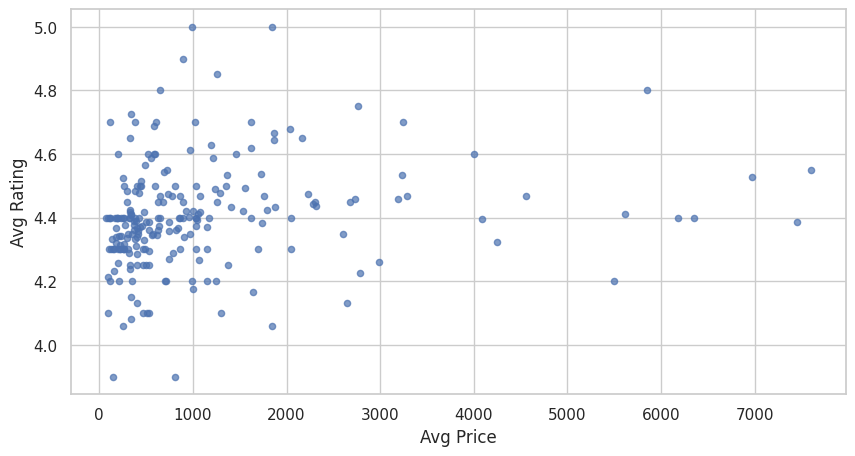

In [82]:
brand_summary = nykaa1.groupby('brand').agg(
    avg_rating=('rating', 'mean'),
    avg_price=('final_price', 'mean'),
    product_count=('name', 'count')
).reset_index()

brand_summary.plot(kind='scatter', x='avg_price', y='avg_rating', alpha=0.7)
plt.xlabel('Avg Price')
plt.ylabel('Avg Rating')
plt.show()

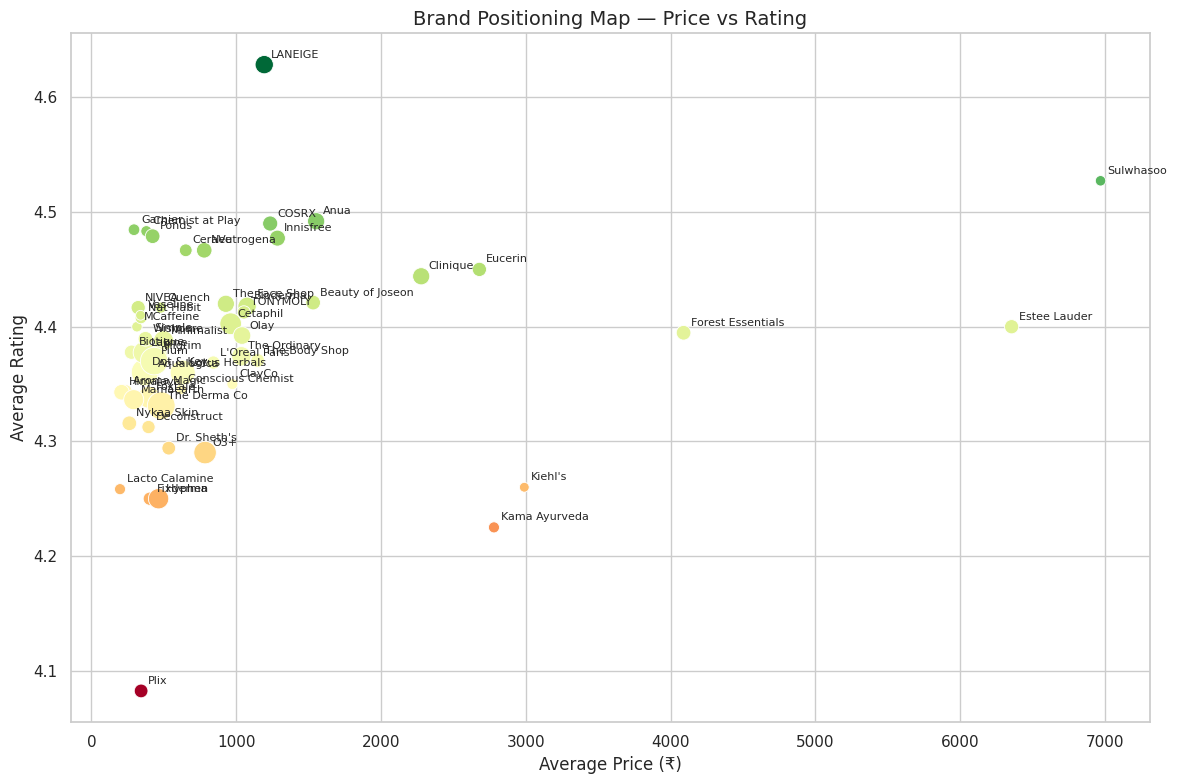

In [83]:
filtered_brands = brand_summary[brand_summary['product_count'] >= 10]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_brands, x='avg_price', y='avg_rating',
                size='product_count', sizes=(50, 400),
                hue='avg_rating', palette='RdYlGn', legend=False)


for _, row in filtered_brands.iterrows():
    plt.annotate(row['brand'], (row['avg_price'], row['avg_rating']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Average Price (₹)')
plt.ylabel('Average Rating')
plt.title('Brand Positioning Map — Price vs Rating')
plt.tight_layout()
plt.show()

### Insight — Brand Positioning Map

**Best value quadrant (low price, high rating):**
- LANEIGE — highest rated (*~4.65*) at moderate price (~₹1200)
  — outstanding value for a premium Korean brand
- COSRX, Anua, Innisfree — Korean brands clustering at
  high rating, low-mid price — K-beauty value proposition
  is clearly working in India
- Neutrogena, CeraVe — high rating under ₹500 —
  best mass market value brands

**Premium justified (high price, high rating):**
- Sulwhasoo (~₹7000, 4.52) — most expensive brand but
  delivers on rating — luxury K-beauty
- Estee Lauder (~₹6500, 4.44) — premium Western brand,
  rating decent but not exceptional for the price
- Clinique, Eucerin — mid-premium, solid ratings

**Underperformers (low/mid price, low rating):**
- Flix (~4.1) — lowest rated brand, cheapest position —
  worst value in the dataset
- Kama Ayurveda (~₹3000, 4.22) — premium priced but
  underdelivering on rating — overpriced for what it offers
- Lacto Calamine, Fixderma — budget priced but below
  average rating

**Crowded middle:**
- The Derma Co, Minimalist, Plum, Dot & Key — all
  clustered at ₹300–800, rating 4.3–4.4 — intense
  competition in the D2C mid-market segment,
  no clear winner

**Key takeaway:**
Korean beauty brands (LANEIGE, COSRX, Anua, Innisfree)
dominate the best-value quadrant — high quality at
accessible prices. Indian D2C brands (Derma Co, Dot & Key,
Minimalist) are competitive on price but haven't
differentiated on rating. Legacy Indian brands
(Kama Ayurveda, Lacto Calamine) are either overpriced
or underperforming.

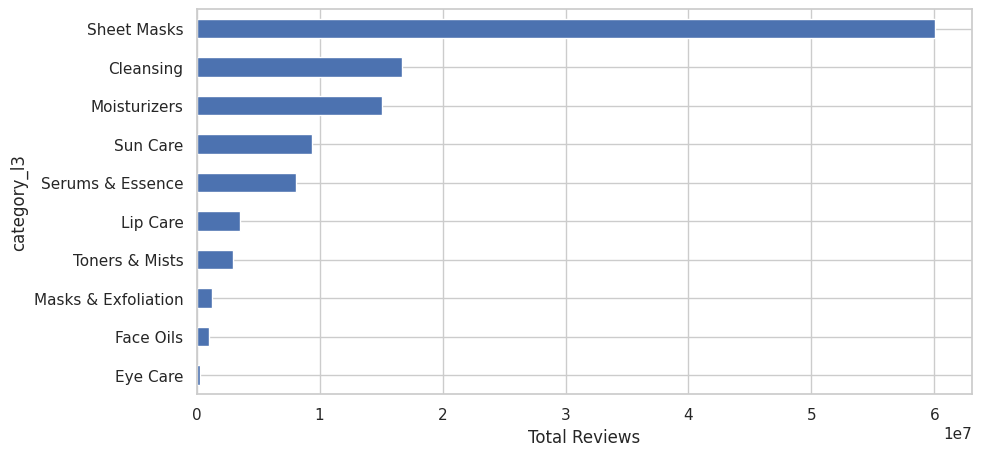

In [84]:
nykaa1.groupby('category_l3')['review_count'].sum().sort_values().plot(kind='barh')
plt.xlabel('Total Reviews')
plt.show()

In [85]:
print(nykaa1[nykaa1['category_l3'] == 'Sheet Masks']['review_count'].sort_values(ascending=False))

201     7327950
410     7327950
675     7327950
679     7327950
1001    7327950
1379    7327950
1956    7327950
1665    7327950
259      155363
154      155363
1235     155363
2042     155363
338      155363
16       155363
1602      88544
81        88544
1370      58334
1633      58334
2166      27184
2439      27184
1609      27184
2150      24270
2338      24270
289       10105
282       10105
29        10105
2479       1844
535        1270
1896       1270
2267       1270
2020       1090
2283        833
2292        722
1531        722
307         722
1330        722
644         722
2122        722
1121        722
1312        622
1839        466
1205        455
2163        455
2268        404
2231        389
2126        386
1688        339
1930        300
1850        147
102         146
1934        146
2151         41
1630          7
2284          5
712           2
2021          2
2054          1
2200          1
Name: review_count, dtype: Int64


### Note — Outlier Handling
The value 7,327,950 appears identically across 8 different
products in Sheet Masks — this is a data quality issue
from scraping (same review count assigned to multiple
products). Including it would make Sheet Masks appear as
the most reviewed category by a massive margin, which is
misleading. These rows are excluded from review-count
analysis only — they remain in all other analyses.

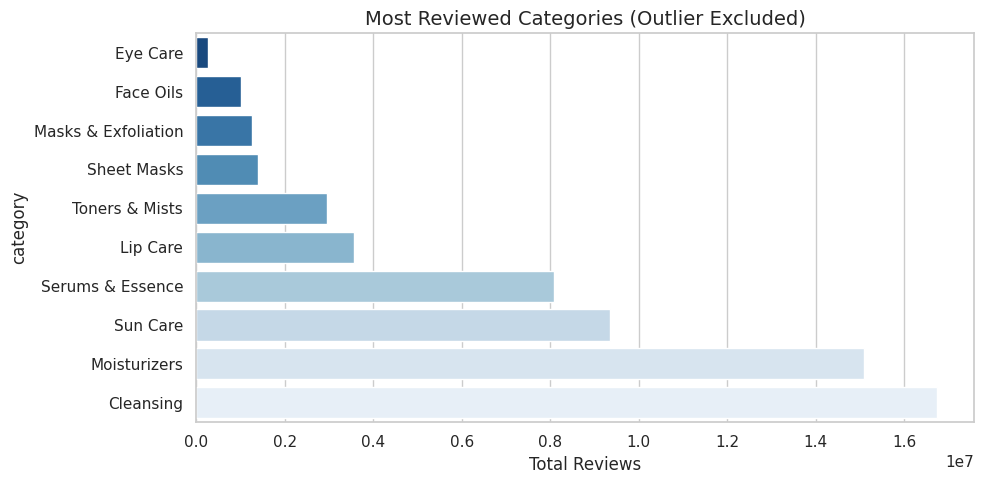

In [86]:
clean_reviews = nykaa1[nykaa1['review_count'] != 7327950]

# Add .notna() filter here to exclude NaN categories
review_by_cat = clean_reviews[clean_reviews['category_l3'].notna()].groupby('category_l3')['review_count'].sum().sort_values().reset_index()
review_by_cat.columns = ['category', 'total_reviews']

sns.barplot(data=review_by_cat, x='total_reviews', y='category',
            hue='category', palette='Blues_r', legend=False)
plt.xlabel('Total Reviews')
plt.title('Most Reviewed Categories (Outlier Excluded)')
plt.tight_layout()
plt.show()

### Insight — Most Reviewed Categories (Outlier Excluded)

- Cleansing leads with ~16M total reviews — makes sense
  as face wash is a daily-use, high-repurchase product
  that accumulates reviews over time
- Moisturizers at ~15M — equally dominant, daily use
  drives consistent review accumulation
- These two categories together account for the majority
  of all consumer engagement on Nykaa skincare
- Sun Care at ~9M — reflects rapidly growing SPF awareness
  in India, strong engagement despite being a newer habit
- Serums & Essence at ~8M — impressive for a category
  that's relatively newer in Indian skincare — signals
  strong and growing consumer interest
- Lip Care (*~3.5M*) and Toners & Mists (~3M) are mid-tier
  — consistent but not dominant engagement
- Sheet Masks (*~1.5M* after outlier removal),
  Masks & Exfoliation (*~1.2M*), Face Oils (~0.9M)
  — low engagement, niche categories
- Eye Care barely registers — very low consumer
  engagement despite being a distinct category

**Key takeaway:**
Review volume directly tracks purchase frequency —
daily use categories (Cleansing, Moisturizers) dominate.
The gap between Sun Care (9M) and treatments like
Masks (1.2M) shows Indian consumers prioritise
protection and hydration over targeted treatments.

In [111]:
routine_categories = ['Cleansing', 'Serums & Essence', 'Moisturizers', 'Sun Care']

for cat in routine_categories:
    subset = nykaa1[
        (nykaa1['category_l3'] == cat) &
        (nykaa1['final_price'] <= 1000)
    ]



    subset = subset.copy()
    subset['credibility_score'] = subset['rating'] * np.log1p(subset['review_count'])
    best = subset.sort_values('credibility_score', ascending=False).iloc[0]

    print(f"\n{cat}")
    print(f"  Product: {best['name']}")
    print(f"  Brand:   {best['brand']}")
    print(f"  Price:   ₹{best['final_price']}")
    print(f"  Rating:  {best['rating']}")
    print(f"  Reviews: {best['review_count']}")
    print(f"  Credibility Score: {best['credibility_score']:.2f}")


Cleansing
  Product: Nykaa Naturals Tea Tree & Neem Detox Face Scrub For Purifying, Acne Control & Clear Skin Glow
  Brand:   Nykaa Skin
  Price:   ₹237.0
  Rating:  4.3
  Reviews: 873094
  Credibility Score: 58.82

Serums & Essence
  Product: The Ordinary Multi-Peptide + Copper Peptides 1% Serum
  Brand:   The Ordinary
  Price:   ₹600.0
  Rating:  4.5
  Reviews: 155330
  Credibility Score: 53.79

Moisturizers
  Product: Ponds Ultra Light Biome Gel With Cera - Hyamino
  Brand:   Ponds
  Price:   ₹498.0
  Rating:  5.0
  Reviews: 646538
  Credibility Score: 66.90

Sun Care
  Product: Neutrogena Ultrasheer SPF50+ PA+++ Ultra Light Face Sunscreen For Dry & Oily Skin Super Value Pack
  Brand:   Neutrogena
  Price:   ₹649.0
  Rating:  4.4
  Reviews: 315549
  Credibility Score: 55.71


In [112]:
routine_categories = ['Cleansing', 'Serums & Essence', 'Moisturizers', 'Sun Care']

for cat in routine_categories:
    subset = nykaa1[(nykaa1['category_l3'] == cat) & (nykaa1['final_price'] <= 300)]


    subset = subset.copy()
    subset['credibility_score'] = subset['rating'] * np.log1p(subset['review_count'])
    best = subset.sort_values('credibility_score', ascending=False).iloc[0]

    print(f"\n{cat}")
    print(f"  Product: {best['name']}")
    print(f"  Brand: {best['brand']}")
    print(f"  Price: ₹{best['final_price']}")
    print(f"  Rating: {best['rating']}")


Cleansing
  Product: Nykaa Naturals Tea Tree & Neem Detox Face Scrub For Purifying, Acne Control & Clear Skin Glow
  Brand: Nykaa Skin
  Price: ₹237.0
  Rating: 4.3

Serums & Essence
  Product: Garnier Bright Complete Vitamin C+ Serum with 10% Pure Vitamin C to Repair & Brighten Skin
  Brand: Garnier
  Price: ₹284.0
  Rating: 4.6

Moisturizers
  Product: Lakme Absolute Hydra Pro Gel Creme
  Brand: Lakme
  Price: ₹291.0
  Rating: 4.5

Sun Care
  Product: Foxtale SPF 70 Gel-Cream Sunscreen for Oily Skin with PA++++ & Niacinamide
  Brand: Foxtale
  Price: ₹297.0
  Rating: 4.4


### Data-Driven AM Routine — Under ₹1000 per product

| Step | Product | Brand | Price | Rating | Reviews | Credibility |
|---|---|---|---|---|---|---|
| Cleansing | Nykaa Naturals Tea Tree & Neem Detox Face Scrub | Nykaa Skin | ₹237 | 4.3 | 873,094 | 58.82 |
| Serum | The Ordinary Multi-Peptide + Copper Peptides 1% | The Ordinary | ₹600 | 4.5 | 155,330 | 53.79 |
| Moisturizer | Ponds Ultra Light Biome Gel With Cera - Hyamino | Ponds | ₹498 | 5.0 | 646,538 | 66.90 |
| Sunscreen | Neutrogena Ultrasheer SPF50+ PA+++ Ultra Light | Neutrogena | ₹649 | 4.4 | 315,549 | 55.71 |

**Total: ₹1984** | All ranked by credibility score, not raw rating
All products have 150,000+ reviews — statistically reliable recommendations

---

### Student Special — Under ₹300 per product

| Step | Product | Brand | Price | Rating |
|---|---|---|---|---|
| Cleansing | Nykaa Naturals Tea Tree & Neem Detox Face Scrub | Nykaa Skin | ₹237 | 4.3 |
| Serum | Garnier Bright Complete Vitamin C+ Serum | Garnier | ₹284 | 4.6 |
| Moisturizer | Lakme Absolute Hydra Pro Gel Creme | Lakme | ₹291 | 4.5 |
| Sunscreen | Foxtale SPF 70 Gel-Cream Sunscreen with Niacinamide | Foxtale | ₹297 | 4.4 |

**Total: ₹1109** | Complete AM routine under ₹1200
Quality not compromised — all products rated above 4.3

---

### Key Insight
- A complete data-driven AM skincare routine (Cleanse →
  Treat → Moisturize → Protect) costs as little as ₹1109
- The ₹1984 routine uses credibility-ranked products with
  100,000+ reviews each — highest trust recommendations
- Ponds dominates both routines in moisturizer step —
  consistently best value moisturizer on Nykaa
- Korean and international brands (The Ordinary, Neutrogena)
  offer best serum and sunscreen value in the ₹1000 routine
- Indian brands (Garnier, Lakme, Foxtale) dominate the
  budget routine — strong value proposition at ₹300 price point

# Key Findings

## 1. Ratings are heavily inflated and compressed
- Mean = 4.39, Median = 4.4, Skew = -1.624
- 84% of products fall between 4.0–4.5 — raw star rating
  is practically useless as a differentiator
- Solution: Credibility Score (rating × log(reviews))
  provides a more reliable signal

## 2. Price ≠ Quality
- Correlation (price vs rating) = 0.10 — negligible
- A ₹300 product is just as likely to be rated 4.5
  as a ₹3000 one
- Premium pricing is a brand positioning choice,
  not a quality signal

## 3. Discounting is purely strategic
- Correlation (discount vs rating) = -0.0005 — essentially zero
- Premium brands (O3+, Hyphen) discount ~5% to protect
  price integrity
- Mass brands (Lakme) discount 25–30% as volume lever
- Discounts signal strategy, not product quality

## 4. Popularity is independent of quality
- Correlation (review count vs rating) = 0.0003 — zero
- A product with 50 reviews rates the same as one
  with 50,000 reviews on average

## 5. Pricing is mass-market dominated
- Median = ₹529, Mean = ₹1032, Max = ₹15,215
- 75% of products under ₹1169
- Premium is a thin tail — mass market dominates everywhere

## 6. Korean beauty brands lead on value
- LANEIGE, COSRX, Anua, Innisfree — high rating at
  accessible prices
- Indian D2C brands (Derma Co, Dot & Key, Minimalist)
  competitive on price but undifferentiated on rating
- Legacy Indian brands (Kama Ayurveda) overpriced
  relative to their ratings

## 7. Brand strategy is visible in discount behaviour
- Two clear archetypes: premium (protect price)
  vs mass (promote aggressively)
- O3+ uniquely owns Masks & Exfoliation category —
  no competitor concentrates there
- Lotus Herbals 68% of products are moisturizers —
  single category dependence risk

## 8. Ingredient ecosystem is standardised
- Glycerin (*~820*), Phenoxyethanol (*~500*), Niacinamide (~460)
  are universal across all price points
- Fragrance appears in budget but NOT premium —
  the clearest formulation difference between tiers
- Niacinamide is now a commodity active — no longer
  a premium differentiator

## 9. Category demand follows daily routine
- Cleansing (*~16M* reviews) and Moisturizers (~15M) dominate
  — daily use drives engagement
- Sheet Masks, Face Oils — niche low-engagement categories
- Sun Care growing rapidly — SPF awareness increasing in India

## 10. A complete AM routine costs as little as ₹1109
- Data-driven recommendations ranked by credibility score
- All recommended products have 100,000+ reviews
- Quality is not compromised at budget price points —
  Nykaa's mass market delivers genuine value